# Comparing the quality of chromatin accessibility profiling generated by dATAC and s3-ATAC

# Import R libraries

In [1]:
suppressPackageStartupMessages({
    library("ArchR")
    library("dplyr")
    library("Matrix")
    library("msigdbr")
    library("GSVA")
    library("readr")
    library("stringr")
    library("BSgenome.Hsapiens.UCSC.hg38")
    library("reticulate")
    library("eulerr")
    library("ggplot2")
})


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

## Load ArchR project

In [48]:
# Fix random number generator to that used locally 
RNGkind("L'Ecuyer-CMRG")

# Set thread count
addArchRThreads(threads = 1)

# Load ArchR project

proj <- loadArchRProject(path = "../../Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results",
                         force = FALSE)

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
        

## Dimensionality reduction and clustering

In [31]:
# LSI dimensionality reduction
proj <- addIterativeLSI(
  ArchRProj = proj,
  useMatrix = "TileMatrix", 
  name = "IterativeLSI", 
  iterations = 4, 
  clusterParams = list( #See Seurat::FindClusters
    resolution =c(0.1,0.5,1,2), 
    sampleCells = 10000, 
    n.start = 10
  ), 
  varFeatures = 25000, 
  dimsToUse = 1:30,
  force = TRUE
)

# Batch effect correction 
Mode <- c()
Mode[grep("_ATAC", proj$cellNames)] <- "ATAC"
Mode[grep("_DATAC", proj$cellNames)] <- "DATAC"
proj$Mode <- Mode

# batch effect correction
proj <- addHarmony(
  ArchRProj = proj,
  reducedDims = "IterativeLSI",
  name = "Harmony",
  groupBy = c("Mode"),
  force = TRUE,
  seed = 7
)

# Clustering using Seurat

proj <- addClusters(
    input = proj,
    reducedDims = "Harmony",
    method = "Seurat",
    name = "Clusters",
    resolution = 0.1,
    dimsToUse = c(1:30), 
    scaleDims=NULL,
    maxClusters = 50,
    force = TRUE
  )


proj <- addUMAP(
  ArchRProj = proj, 
  reducedDims = "Harmony", 
  name = "UMAP", 
  nNeighbors = 30, 
  minDist = 0.5, 
  metric = "cosine",
  force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-dfed6e33547c-Date-2026-02-24_Time-22-42-25.981248.log
If there is an issue, please report to github with logFile!

2026-02-24 22:42:28.166122 : Computing Total Across All Features, 0.021 mins elapsed.

2026-02-24 22:42:30.28676 : Computing Top Features, 0.056 mins elapsed.

###########
2026-02-24 22:42:31.5519 : Running LSI (1 of 4) on Top Features, 0.077 mins elapsed.
###########

2026-02-24 22:42:31.567599 : Creating Partial Matrix, 0.077 mins elapsed.

2026-02-24 22:43:59.496091 : Computing LSI, 1.543 mins elapsed.

2026-02-24 22:44:31.554405 : Identifying Clusters, 2.077 mins elapsed.

2026-02-24 22:44:41.892061 : Identified 7 Clusters, 2.249 mins elapsed.

2026-02-24 22:44:41.933406 : Saving LSI Iteration, 2.25 mins elapsed.



2026-02-24 22:45:01.692852 : Creating Cluster Matrix on the total Group Features, 2.579 mins elapsed.

2026-02-24 22:47:21.310917 : Computing Variable Features, 4.906 mins elapsed.

####

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7880
Number of edges: 325921

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9588
Number of communities: 7
Elapsed time: 1 seconds


2 singletons identified. 5 final clusters.

2026-02-24 22:58:47.692556 : Testing Biased Clusters, 0.158 mins elapsed.

2026-02-24 22:58:47.720748 : Testing Outlier Clusters, 0.158 mins elapsed.

2026-02-24 22:58:47.735253 : Assigning Cluster Names to 5 Clusters, 0.159 mins elapsed.

2026-02-24 22:58:47.774842 : Finished addClusters, 0.159 mins elapsed.

22:58:47 UMAP embedding parameters a = 0.583 b = 1.334

22:58:47 Read 7880 rows and found 29 numeric columns

22:58:47 Using Annoy for neighbor search, n_neighbors = 30

22:58:47 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

22:58:48 Writing NN index file to temp file /var/folders/f3/1rtmfwtj5bg3c32s2xf8fpdn1m18m5/T//RtmpdxP7tA/filedfed2aa1dc3b

22:58:48 Searching Annoy index using 4 threads, search_k = 3000

22:58:49

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-dfed3d011b04-Date-2026-02-25_Time-08-36-19.252373.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-dfed3d011b04-Date-2026-02-25_Time-08-36-19.252373.log



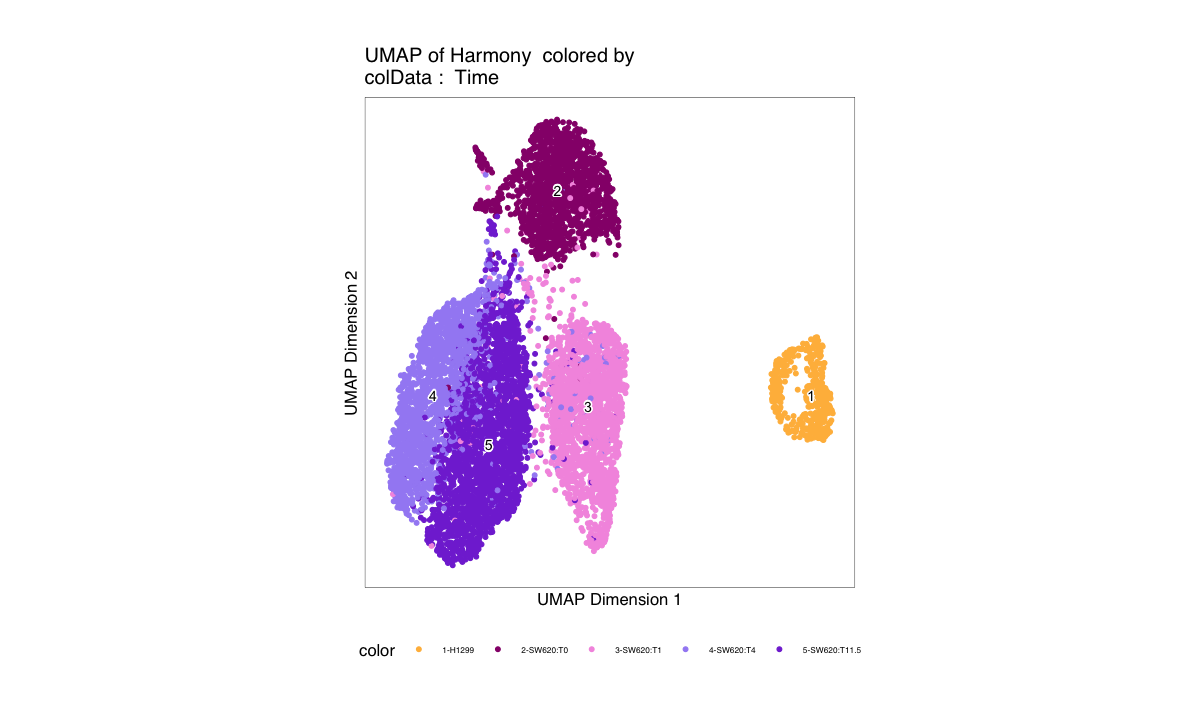

In [58]:
# Chromatin accessibility UMAP colored by cell line:timepoint

time <- c()
time[grep("POTa|POTb", proj$cellNames)] <- "SW620:T0"
time[grep("DSIa|DSIb", proj$cellNames)] <- "SW620:T1"
time[grep("DSIVa|DSIVb", proj$cellNames)] <- "SW620:T4"
time[grep("DT1_P1a|DT1_P1b", proj$cellNames)] <- "SW620:T11.5"
time[grep("H1299", proj$cellNames)] <- "H1299"

proj$Time <- time

p1 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Time", embedding = "UMAP",
                    size = 1,
                    pal = c("SW620:T0" = "#961179",
                            "SW620:T1" =  "#F49AE1",
                            "SW620:T4" = "#A48EF4",
                            "SW620:T11.5"= "#8239D6",
                            "H1299" = "#ffba49"),
                    theme = theme_ArchR(
                      legendPosition = "right",
                      legendTextSize = 20, # Adjust this value
                      baseSize = 24 # Adjust this value as well
                    ),plotAs = "points",
                    rastr = F)
p1

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-dfed78d8393c-Date-2026-02-25_Time-08-36-10.994784.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-dfed78d8393c-Date-2026-02-25_Time-08-36-10.994784.log



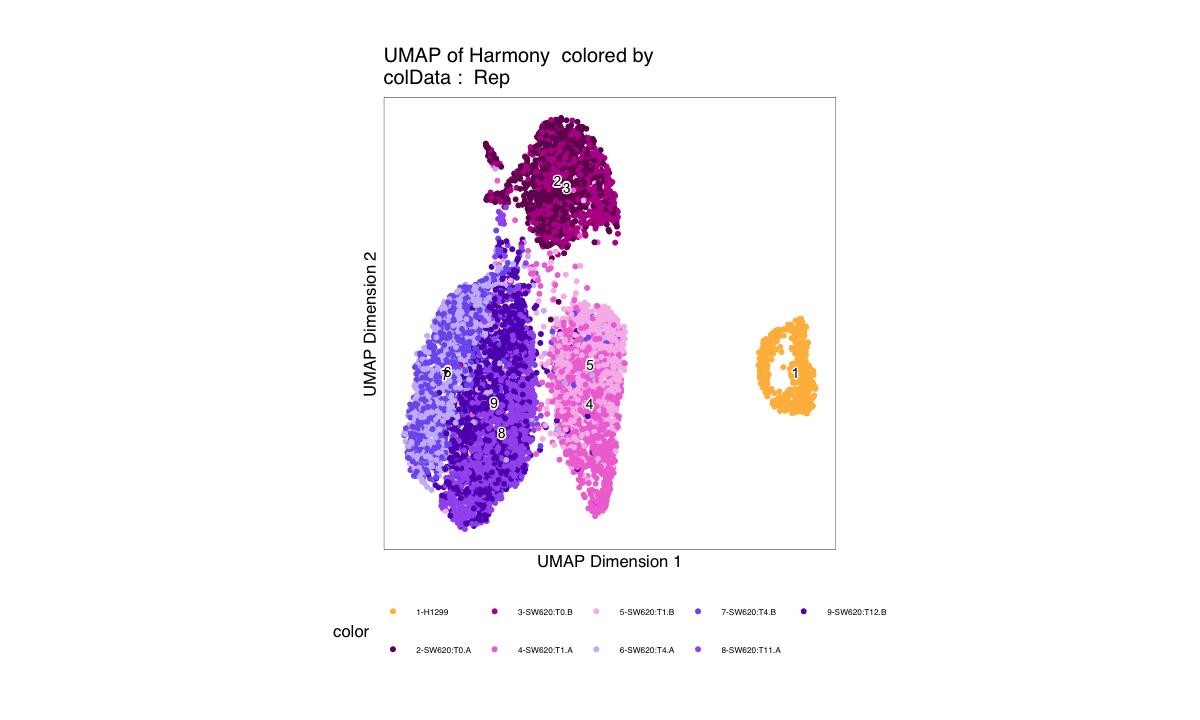

In [57]:
# Chromatin accessibility UMAP colored by cell line:replicate

rep <- c()
rep[grep("POTa", proj$cellNames)] <- "SW620:T0.A"
rep[grep("POTb", proj$cellNames)] <- "SW620:T0.B"
rep[grep("DSIa", proj$cellNames)] <- "SW620:T1.A"
rep[grep("DSIb", proj$cellNames)] <- "SW620:T1.B"
rep[grep("DSIVa", proj$cellNames)] <- "SW620:T4.A"
rep[grep("DSIVb", proj$cellNames)] <- "SW620:T4.B"
rep[grep("DT1_P1a", proj$cellNames)] <- "SW620:T11.A"
rep[grep("DT1_P1b", proj$cellNames)] <- "SW620:T12.B"
rep[grep("H1299", proj$cellNames)] <- "H1299"

proj$Rep <- rep

p1 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Rep", embedding = "UMAP",
                    size = 1,
                    pal = c("SW620:T0.A" = "#730d5d",
                            "SW620:T0.B" = "#b81595",
                            "SW620:T1.A" =  "#f077d6",
                            "SW620:T1.B" =  "#f8bceb",
                            "SW620:T4.A" = "#c9bcf8",
                            "SW620:T4.B" = "#7e60ef",
                            "SW620:T11.A"= "#a25fef",
                            "SW620:T12.B"= "#6113bc",
                            "H1299" = "#ffba49"),
                    theme = theme_ArchR(
                      legendPosition = "right",
                      legendTextSize = 20, # Adjust this value
                      baseSize = 24 # Adjust this value as well
                    ),plotAs = "points",
                    rastr = F)
p1

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-dfed2d416842-Date-2026-02-25_Time-08-36-28.753701.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-dfed2d416842-Date-2026-02-25_Time-08-36-28.753701.log



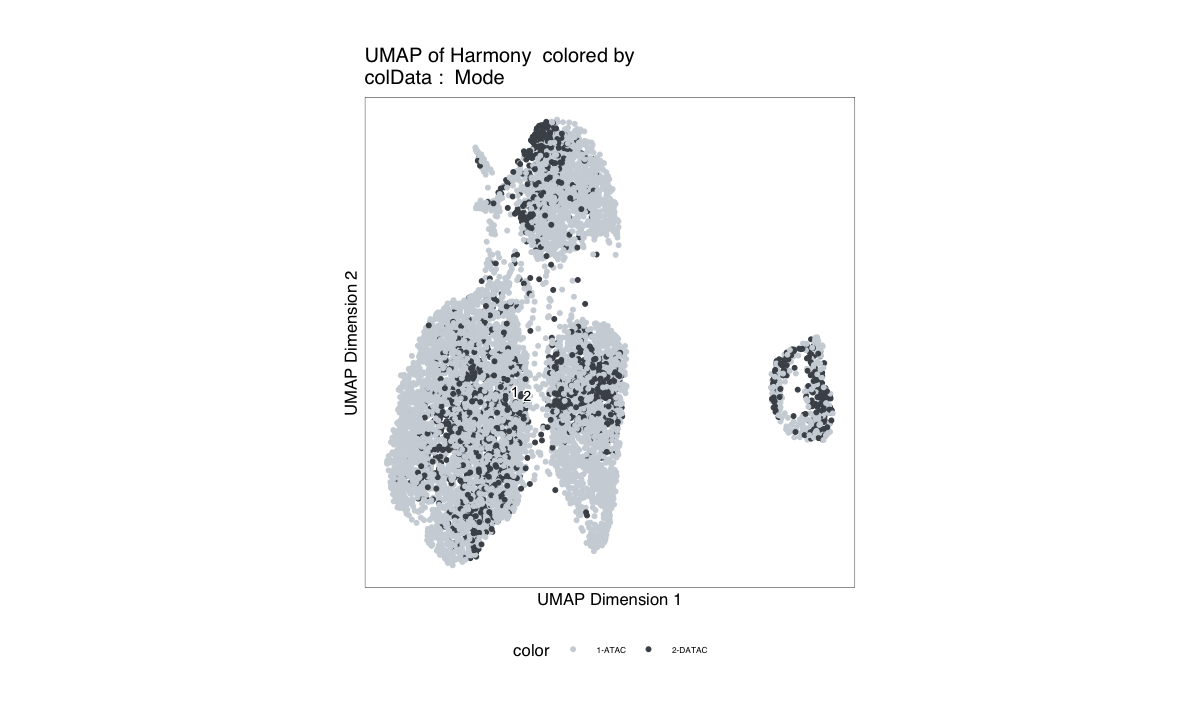

In [59]:
# Chromatin accessibility UMAP colored by assay (dATAC vs s3-ATAC)

p1 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Mode", embedding = "UMAP",
                    size = 1,
                    pal = c("ATAC" = "#ced4da",
                            "DATAC" =  "#495057"),
                    theme = theme_ArchR(
                      legendPosition = "right",
                      legendTextSize = 24, # Adjust this value
                      baseSize = 30 # Adjust this value as well
                    ),plotAs = "points",
                    rastr = F)

p1

## Call peaks to compare FRIP and correlations between dATAC and s3-ATAC

In [35]:
# Add group coverages for peak calling
proj <- addGroupCoverages(ArchRProj = proj, groupBy = "Clusters")

# Set the path to Macs2
pathToMacs2 <- findMacs2()

# Call peaks using Macs2
proj <- addReproduciblePeakSet(
  ArchRProj = proj, 
  groupBy = "Clusters", 
  pathToMacs2 = pathToMacs2
)

# Retrieve a GRanges object containing the peak information (position, signal, etc.)
peaks <- getPeakSet(proj)

# Add peak matrix to the project
proj <- addPeakMatrix(proj)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-dfed27a8c0ef-Date-2026-02-24_Time-22-59-51.584293.log
If there is an issue, please report to github with logFile!

C1 (1 of 5) : CellGroups N = 2

C2 (2 of 5) : CellGroups N = 2

C3 (3 of 5) : CellGroups N = 5

C4 (4 of 5) : CellGroups N = 5

C5 (5 of 5) : CellGroups N = 5

2026-02-24 22:59:54.196501 : Further Sampled 6 Groups above the Max Fragments!, 0.044 mins elapsed.

2026-02-24 22:59:54.618578 : Creating Coverage Files!, 0.051 mins elapsed.

2026-02-24 22:59:54.620607 : Batch Execution w/ safelapply!, 0.051 mins elapsed.

2026-02-24 22:59:54.643218 : Group C1._.H1299_ATAC (1 of 19) : Creating Group Coverage File : C1._.H1299_ATAC.insertions.coverage.h5, 0.051 mins elapsed.

Number of Cells = 215

Coverage File Exists!

Added Coverage Group

Added Metadata Group

Added ArrowCoverage Class

Added Coverage/Info

Added Coverage/Info/CellNames

2026-02-24 23:00:31.053508 : Group C1._.H1299_DATAC (2 of 19) : Creating Group Coverage F

   Group nCells nCellsUsed nReplicates nMin nMax maxPeaks
C1    C1    396        396           2  181  215   150000
C2    C2     72         64           2   40   40    32000
C3    C3   1592       1354           5   54  500   150000
C4    C4   1766       1389           5   59  500   150000
C5    C5   4054       2318           5  318  500   150000


2026-02-24 23:17:37.307014 : Batching Peak Calls!, 0.023 mins elapsed.

2026-02-24 23:17:37.423911 : Batch Execution w/ safelapply!, 0 mins elapsed.

2026-02-24 23:17:37.431456 : Group 1 of 19, Calling Peaks with MACS2!, 0 mins elapsed.

Running Macs2 with Params : macs2 callpeak -g 2.7e+09 --name C1._.H1299_ATAC-1 --treatment /Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results/PeakCalls/Clusters/InsertionBeds/C1._.H1299_ATAC-1.insertions.bed --outdir /Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results/PeakCalls/Clusters/InsertionBeds --format BED --call-summits --keep-dup all --nomodel --nolambda --shift -75 --extsize 150 -q 0.1

2026-02-24 23:19:10.817402 : Group 2 of 19, Calling Peaks with MACS2!, 1.557 mins elapsed.

Running Macs2 with Params : macs2 callpeak -g 2.7e+09 --name 

[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results/PeakCalls/Clusters/C1-reproduciblePeaks.gr.rds"


Annotating Peaks : Nearest Gene

Annotating Peaks : Gene

Annotating Peaks : TSS

Annotating Peaks : GC



...

[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results/PeakCalls/Clusters/C4-reproduciblePeaks.gr.rds"


Annotating Peaks : Nearest Gene

Annotating Peaks : Gene

Annotating Peaks : TSS

Annotating Peaks : GC



[1] "/Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results/PeakCalls/Clusters/C5-reproduciblePeaks.gr.rds"


2026-02-24 23:39:23.853592 : Creating Union Peak Set!, 21.799 mins elapsed.

Converged after 7 iterations!

Plotting Ggplot!

2026-02-24 23:39:28.221318 : Finished Creating Union Peak Set (235381)!, 21.871 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-addPeakMatrix-dfed287c981c-Date-2026-02-24_Time-23-39-28.23689.log
If there is an issue, please report to github with logFile!

2026-02-24 23:39:28.45683 : Batch Execution w/ safelapply!, 0 mins elapsed.

.createArrowGroup : Arrow Group already exists! Dropping Group from ArrowFile! This will take ~10-30 seconds!

.dropGroupsFromArrow : Initializing Temp ArrowFile

.dropGroupsFromArrow : Adding Metadata to Temp ArrowFile

.dropGroupsFromArrow : Adding SubGroups to Temp ArrowFile

.dropGroupsFromArrow : Move Temp ArrowFile to ArrowFile

2026-02-24 23:39:47.685285 : Adding SW620bc_DSIa_ATAC to PeakMatrix for Chr (1 of 23)!, 0.01 mins elapsed.

2026-02-24 23:39:56.360024 : Adding SW620bc_DSIa_ATAC to PeakMatrix for Chr (2 of 23)!, 0.154 

ERROR: Error in library(ggbeeswarm): there is no package called ‘ggbeeswarm’


In [36]:
saveArchRProject(proj, "../../Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results")

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /Users/ccolson/Documents/LongTermResistance_CellLineWork/dATACManuscript_AssociatedCode_Revision/Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results 
samples(18): SW620bc_DSIa_ATAC SW620bc_DT1_P1a_ATAC ...
  SW620bc_DSIVb_DATAC SW620bc_DSIVa_DATAC
sampleColData names(1): ArrowFiles
cellColData names(27): Sample TSSEnrichment ... FRIP Clusters
numberOfCells(1): 7880
medianTSS(1): 8.637
medianFrags(1): 72847.5

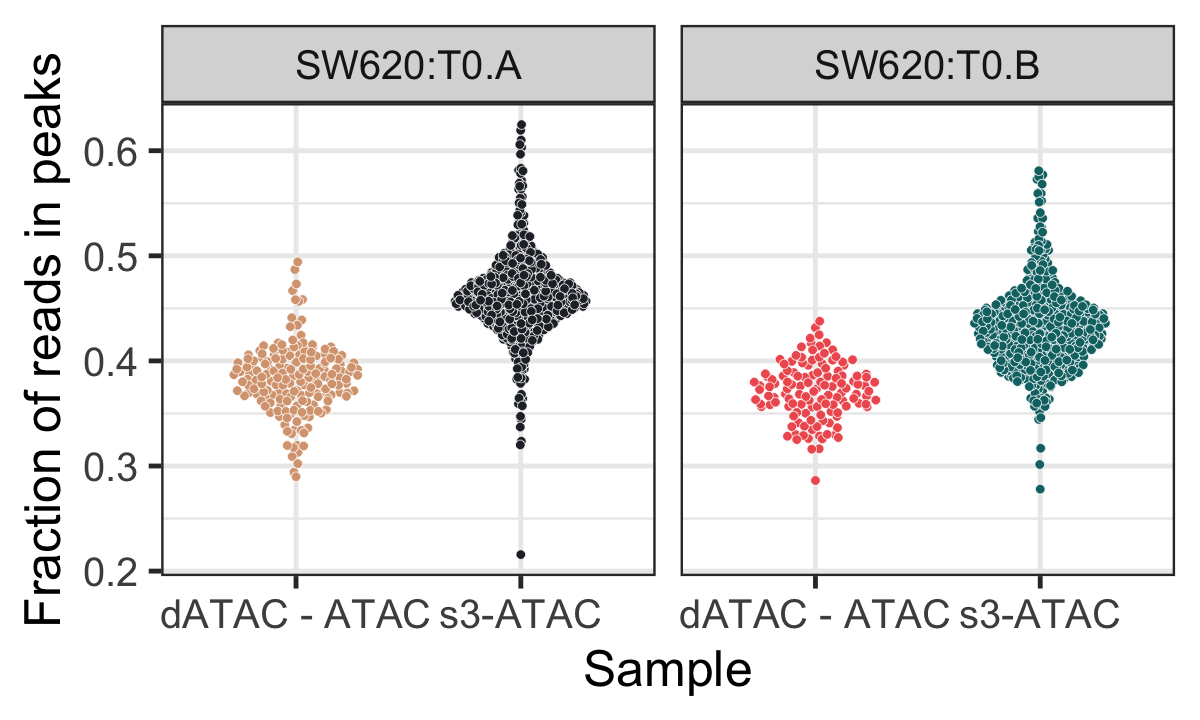

In [43]:
library(ggbeeswarm)

df <- data.frame(proj@cellColData[proj@cellColData$Time %in% c("SW620:T0"),]) %>% mutate(Mode = case_when(Mode == "ATAC"~ "s3-ATAC",
                                                                                                  Mode == "DATAC" ~ "dATAC - ATAC"))
p <- ggplot(data = df, aes(x = Mode, y =FRIP,  fill = Sample))+
  geom_quasirandom(
    dodge.width = 0.75,
    shape = 21,
    color = "white",
    alpha = 1,
    size = 2.5,
    stroke = 0.3,
    width = 0.3,         # how wide the cloud is
    varwidth = TRUE      # makes the dots follow density (violin shape)
  )+
  scale_color_manual(values = c("SW620bc_POTa_DATAC" ="#d8a47f",
                                "SW620bc_POTb_DATAC" ="#f05d5e",
                                "SW620bc_POTb_ATAC" ="#0f7173",
                                "SW620bc_POTa_ATAC" ="#272932"))+
  scale_fill_manual(values = c("SW620bc_POTa_DATAC" ="#d8a47f",
                               "SW620bc_POTb_DATAC" ="#f05d5e",
                               "SW620bc_POTb_ATAC" ="#0f7173",
                               "SW620bc_POTa_ATAC" ="#272932"))+
  facet_wrap(vars(Rep), scales = "free_x", nrow = 1)+
  xlab("Sample")+
  ylab("Fraction of reads in peaks")+
  guides(color = "none", fill = "none")+
  theme_bw(base_size = 30)
options(repr.plot.width=10, repr.plot.height=6)

p

In [84]:
rep <- c()
rep[grep("POTa_ATAC", proj$cellNames)] <- "s3-ATAC: T0.A"
rep[grep("POTa_DATAC", proj$cellNames)] <- "dATAC - ATAC: T0.A"

rep[grep("POTb_ATAC", proj$cellNames)] <- "s3-ATAC: T0.B"
rep[grep("POTb_DATAC", proj$cellNames)] <- "dATAC - ATAC: T0.B"

rep[grep("DSIa_ATAC", proj$cellNames)] <- "s3-ATAC: T1.A"
rep[grep("DSIa_DATAC", proj$cellNames)] <- "dATAC - ATAC: T1.A"

rep[grep("DSIb_ATAC", proj$cellNames)] <- "s3-ATAC: T1.B"
rep[grep("DSIb_DATAC", proj$cellNames)] <- "dATAC - ATAC: T1.B"

rep[grep("DSIVa_ATAC", proj$cellNames)] <- "s3-ATAC: T4.A"
rep[grep("DSIVa_DATAC", proj$cellNames)] <- "dATAC - ATAC: T4.A"

rep[grep("DSIVb_ATAC", proj$cellNames)] <- "s3-ATAC: T4.B"
rep[grep("DSIVb_DATAC", proj$cellNames)] <- "dATAC - ATAC: T4.B"

rep[grep("DT1_P1a_ATAC", proj$cellNames)] <- "s3-ATAC: T11.A"
rep[grep("DT1_P1a_DATAC", proj$cellNames)] <- "dATAC - ATAC: T11.A"

rep[grep("DT1_P1b_ATAC", proj$cellNames)] <- "s3-ATAC: T12.B"
rep[grep("DT1_P1b_DATAC", proj$cellNames)] <- "dATAC - ATAC: T12.B"

rep[grep("H1299_ATAC", proj$cellNames)] <- "s3-ATAC: H1299"
rep[grep("H1299_DATAC", proj$cellNames)] <- "dATAC - ATAC: H1299"

proj$RepMode <- rep

proj$RepMode <- factor(
  proj$RepMode,
  levels = c("s3-ATAC: T0.A", "dATAC - ATAC: T0.A",
             "s3-ATAC: T0.B", "dATAC - ATAC: T0.B",
            "s3-ATAC: T1.A", "dATAC - ATAC: T1.A",
              "s3-ATAC: T1.B", "dATAC - ATAC: T1.B",
            "s3-ATAC: T4.A", "dATAC - ATAC: T4.A",
             "s3-ATAC: T4.B", "dATAC - ATAC: T4.B",
            "s3-ATAC: T11.A", "dATAC - ATAC: T11.A",
              "s3-ATAC: T12.B", "dATAC - ATAC: T12.B",
            "s3-ATAC: H1299", "dATAC - ATAC: H1299")  # your desired order
)

In [ ]:
# Obtain BigWig files containing the ATAC signal, normalised by reads in TSS, for each clone
getGroupBW(
  ArchRProj = proj,
  groupBy = "RepMode",
  normMethod = "ReadsInTSS",
  tileSize = 1000,
)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


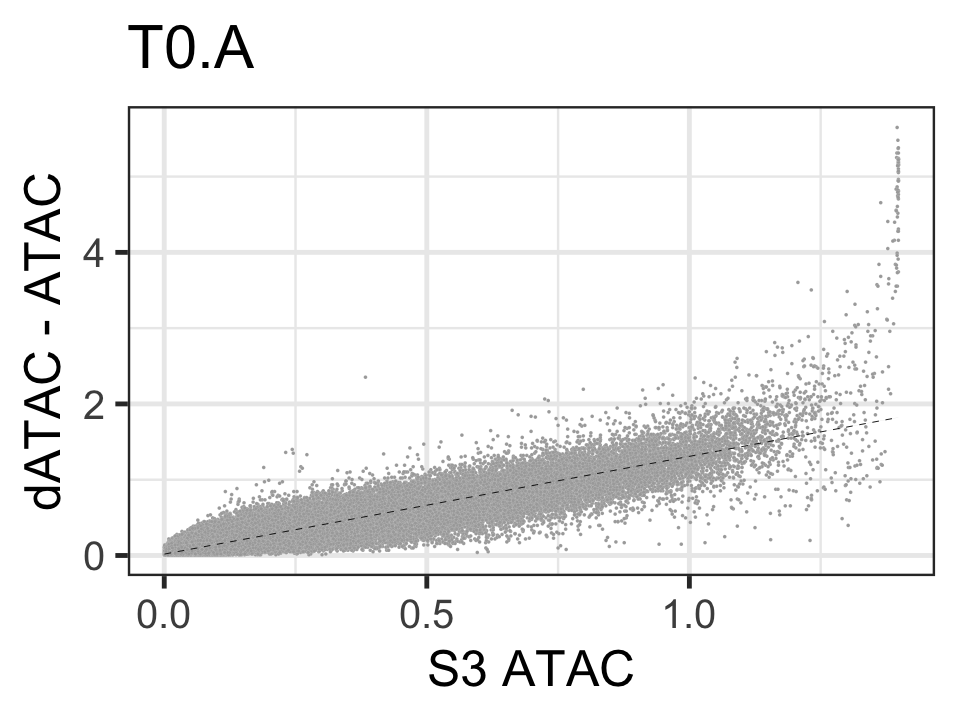

`geom_smooth()` using formula = 'y ~ x'


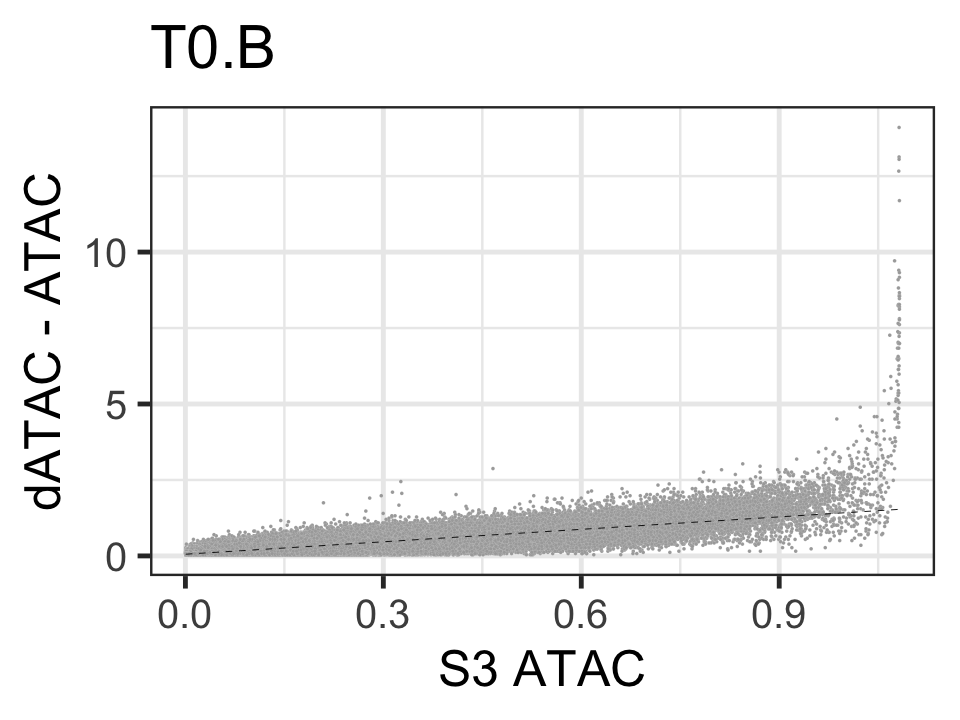

`geom_smooth()` using formula = 'y ~ x'


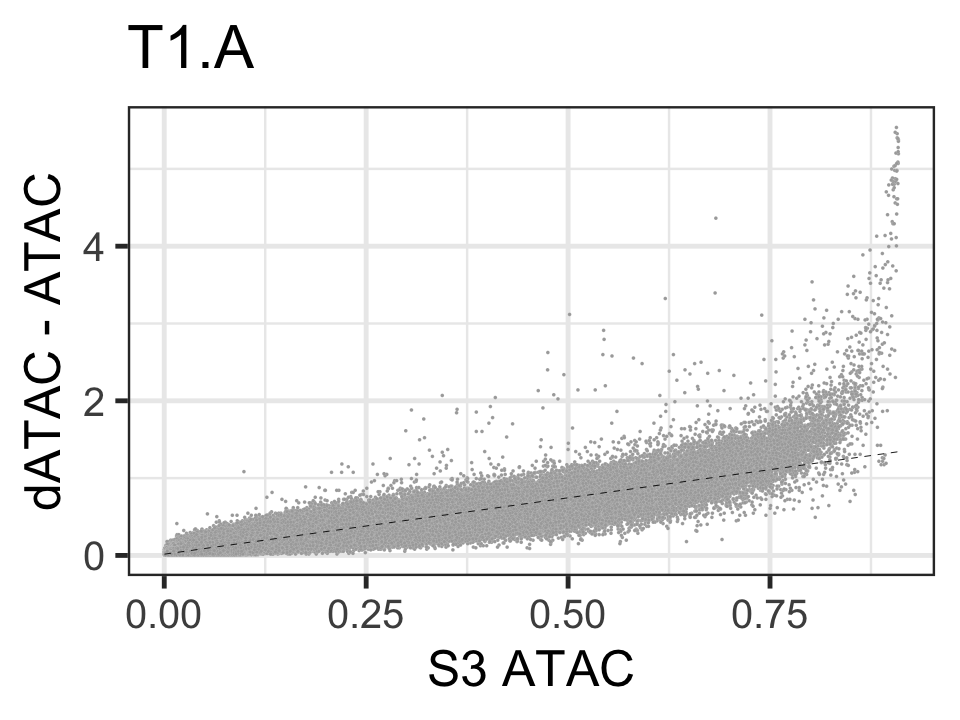

`geom_smooth()` using formula = 'y ~ x'


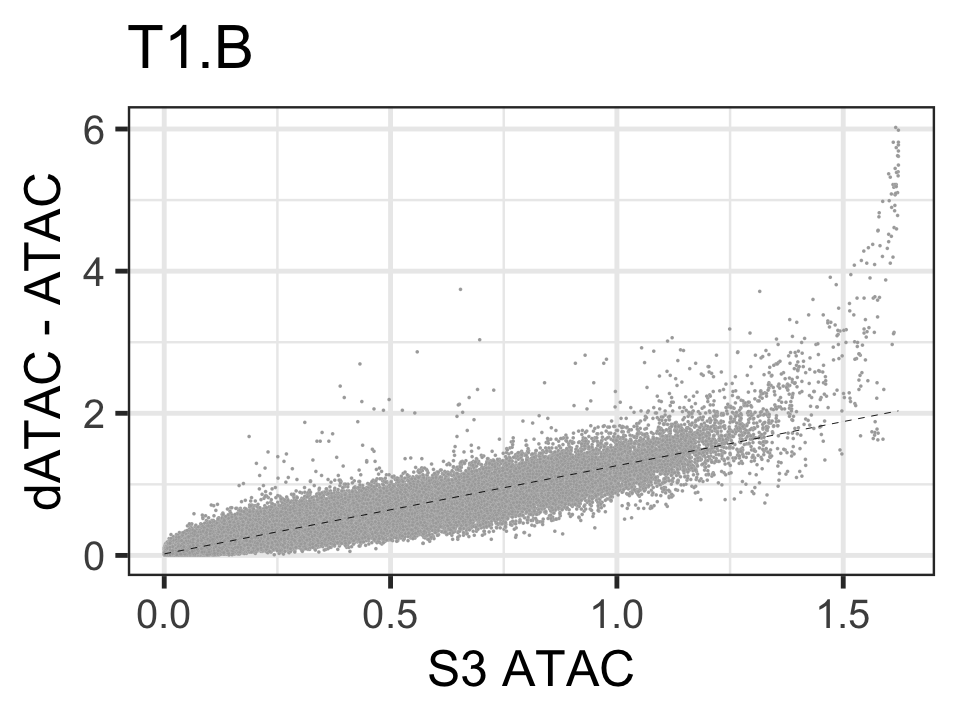

`geom_smooth()` using formula = 'y ~ x'


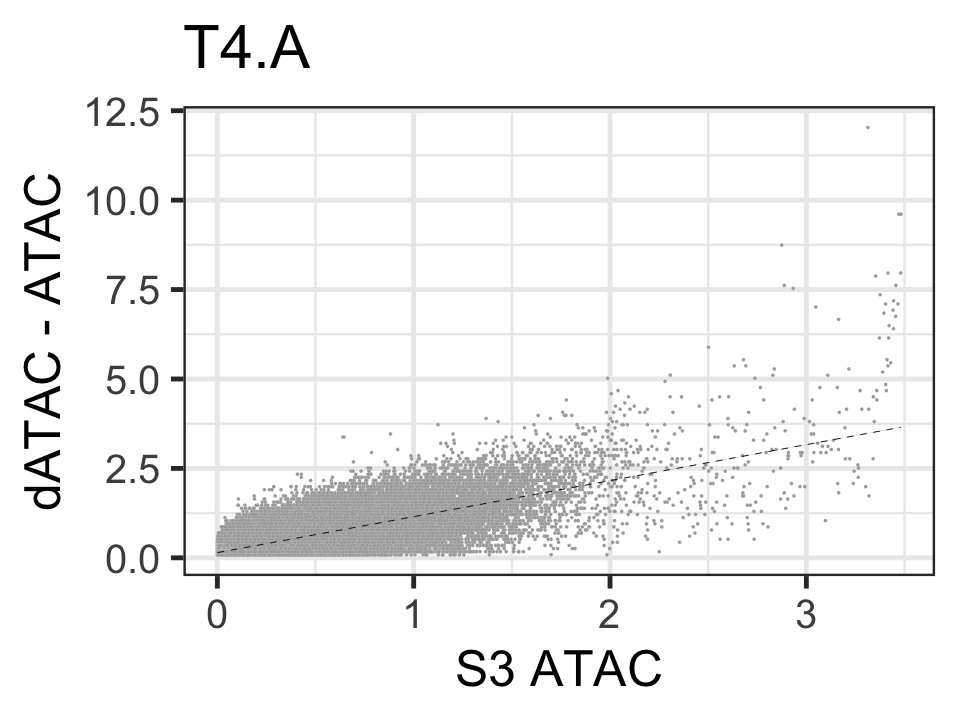

`geom_smooth()` using formula = 'y ~ x'


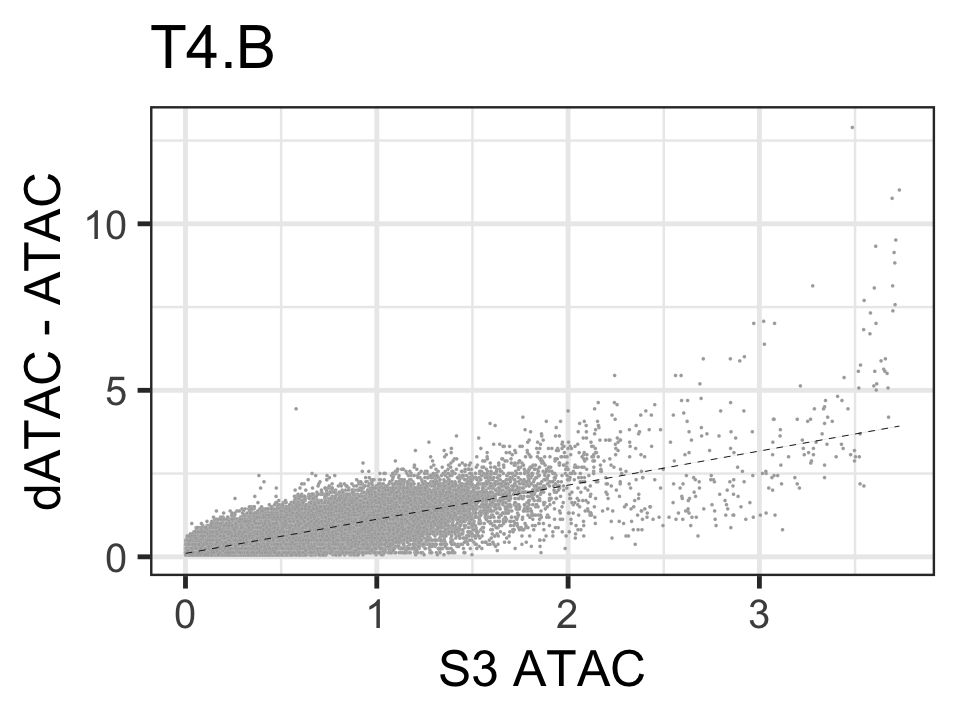

`geom_smooth()` using formula = 'y ~ x'


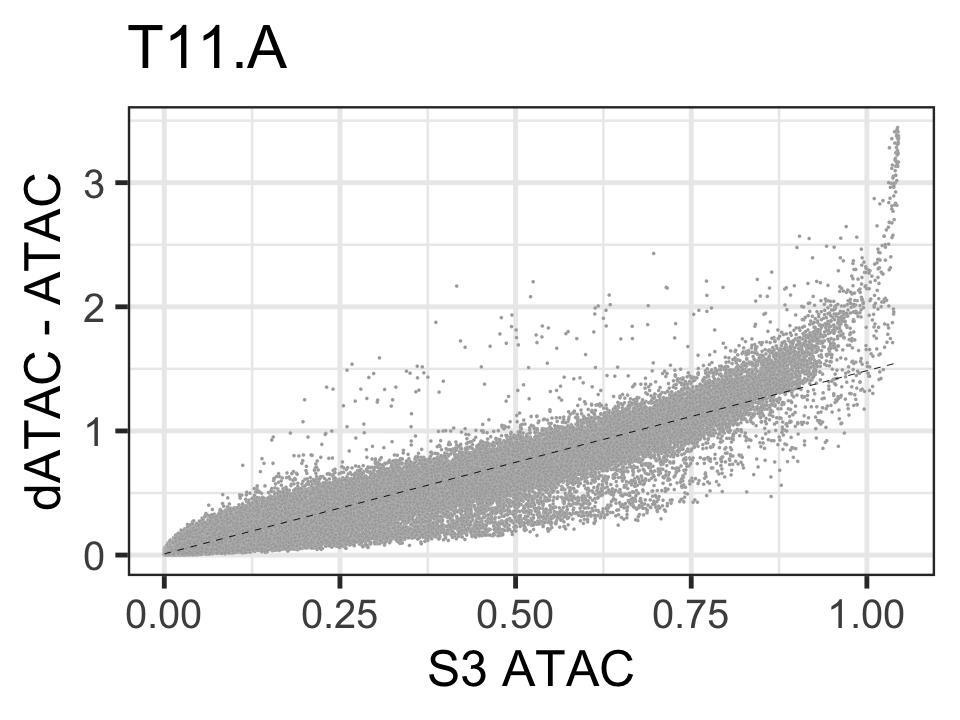

`geom_smooth()` using formula = 'y ~ x'


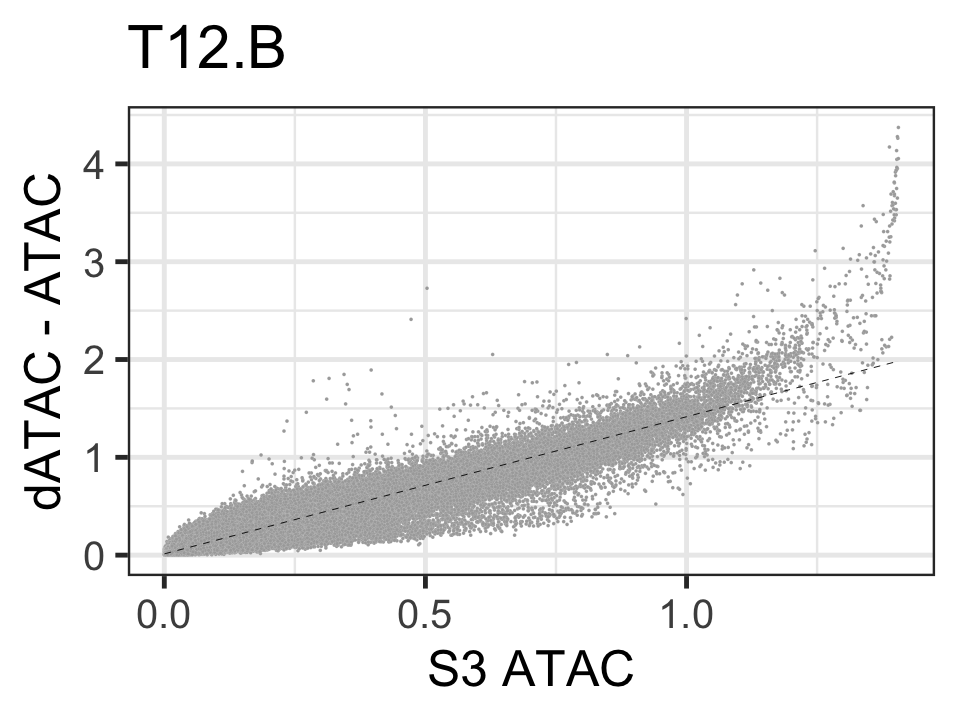

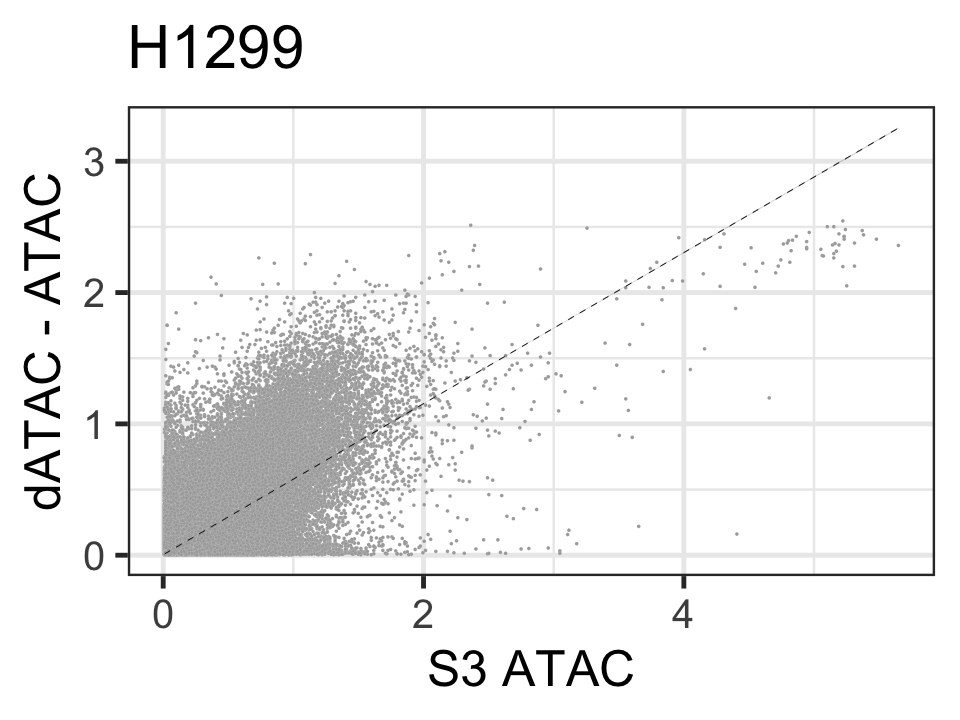

In [145]:
bigwigs <- list.files(path = "../../Data/ArchR_Projects/Save_SW620_H1299_ATAC_DATAC_QC_Results/GroupBigWigs/RepMode",
                      pattern = ".bw", full.names = T)

replicates <- c("T0.A", "T0.B","T1.A", "T1.B","T4.A", "T4.B","T11.A", "T12.B","H1299")

cor_data <- c()
for (r in replicates){
  bw <- bigwigs[grep(r,bigwigs)]
  
  c0_bw <- import.bw(bw[1])
  c1_bw <- import.bw(bw[2])
  
  # 1 Create a common tiling by disjoining both
  common <- disjoin(c(c0_bw, c1_bw))
  
  # 2 Map scores (or other metadata) from each gr back to common bins
  map_scores <- function(from, common) {
    hits <- findOverlaps(common, from)
    mcols(common)$score <- NA  # or whatever metadata columns you want
    mcols(common)$score[queryHits(hits)] <- mcols(from)$score[subjectHits(hits)]
    common
  }
  
  c0_bw_common <- map_scores(c0_bw, common)
  c1_bw_common <- map_scores(c1_bw, common)
  
  mcols(c0_bw_common)[is.na(mcols(c0_bw_common)$score), "score"] <- 0
  mcols(c1_bw_common)[is.na(mcols(c1_bw_common)$score), "score"] <- 0
  
  df <- data.frame("range" = 1:length(c0_bw_common), "SN_0" = c0_bw_common$score, "SN_1" = c1_bw_common$score)
  df <- df %>% filter(SN_0 > 0 & SN_1 > 0)
  
  t <- cor.test(df$SN_0, df$SN_1, method = "pearson")
  cor_data <- rbind(cor_data,cbind("sample" = r, "R" = round(t$estimate,3), "p" = t$p.value))
  
  p <- ggplot(df, aes(x = SN_1, y = SN_0))+
    geom_point(shape = 21, fill = "darkgrey",color = "white", stroke = 0.04, size = 1)+
    geom_smooth(method = "lm",alpha = 0.2, fill = "black", color = "black", linewidth = 0.25, linetype = "dashed")+
    labs(title = sprintf("%s",r))+
    ylab("dATAC - ATAC")+
    xlab("S3 ATAC")+
    guides(color = "none", fill = "none")+
    theme_bw(base_size = 30)
    options(repr.plot.width=8, repr.plot.height=6)
    print(p)
}

#### Correlation scores for each sample

In [144]:
cor_data

,sample,R,p
cor,T0.A,0.931,0
cor,T0.B,0.834,0
cor,T1.A,0.929,0
cor,T1.B,0.94,0
cor,T4.A,0.802,0
cor,T4.B,0.845,0
cor,T11.A,0.967,0
cor,T12.B,0.964,0
cor,H1299,0.74,0


## Compare s3-ATAC and dATAC library complexity

In [74]:
library("readxl")
lib_complexity_1 <- data.frame(read_excel("../../Data/ATAC_Data/QC/SW620_H1299_MCF7_multiqc_picard_dups.xlsx",
                                          sheet = "SW620_BATCH01",
                                          col_types = c(rep("text", 3),rep("numeric", 13),"text"))) 

lib_complexity_1 <- lib_complexity_1[grep("LibraryComplexity",lib_complexity_1$Sample),] %>%
  mutate(new_id = gsub("59|.sort.LibraryComplexity","",Sample))


atac_barcodes <- data.frame(read_excel("../../Data/ATAC_Data/QC/SW620 POT untreated day3 18042024.xlsx",
                                       sheet = "S3_ATAC indexes",
                                       col_types = "text")) 
atac_barcodes <-atac_barcodes %>% 
  select(Sample_Name,Barcode) %>% rename(Sample_Barcode = Barcode) 

atac_barcodes <-atac_barcodes %>% mutate(prefix = sub(".*ATAC#", "", atac_barcodes$Sample_Barcode))

og_names <- proj[proj$Sample %in% c("SW620bc_POTa_ATAC","SW620bc_POTb_ATAC"),]$cellNames

# Extract barcode after `ATAC#`
barcode <- sub(".*ATAC#", "", og_names)

# Define prefix length (adjust if needed)
prefix_len <- 18
suffix_len <- 8

# Identify prefix and suffix
prefix <- substr(barcode, 1, prefix_len)
suffix <- substr(barcode, nchar(barcode)-suffix_len+1, nchar(barcode))

df <- data.frame(
  og_id = og_names,
  barcode = barcode,
  prefix = prefix,
  suffix = suffix,
  stringsAsFactors = FALSE
)

df <- df %>% left_join(atac_barcodes, by = "prefix") 

df <- df %>% mutate(new_id = sprintf("%s_%s",Sample_Name, suffix)) %>% left_join(data.frame("og_id" = proj$cellNames, "sample" = proj@cellColData$Sample), by = "og_id")

#POTa/POTb ATAC
lib_complexity_pot <- lib_complexity_1[lib_complexity_1$new_id %in% df$new_id,] %>% left_join(df[,c("new_id","sample")], by = "new_id")

write_csv(lib_complexity_pot[,c(1:2,4:16,18:19)],"../../Data/ATAC_Data/QC/Processed_ATAC_POT_LibraryComplexities.csv" )

# POTa datac
pota_datac_names <- sub(".*DATAC#", "",rownames(proj@cellColData[proj@cellColData$Sample == "SW620bc_POTa_DATAC",]))
lib_complexity_pota_datac  <- lib_complexity_1[lib_complexity_1$new_id %in% pota_datac_names,] %>% mutate(sample = "SW620bc_POTa_DATAC")

# POTb datac
potb_datac_names <- sub(".*DATAC#", "",rownames(proj@cellColData[proj@cellColData$Sample == "SW620bc_POTb_DATAC",]))
lib_complexity_potb_datac <- data.frame(read_tsv("../../Data/ATAC_Data/QC/LibComplexity_POTb_DATAC.tsv"))
lib_complexity_potb_datac <- lib_complexity_potb_datac[lib_complexity_potb_datac$Sample %in% potb_datac_names,]%>% mutate(sample = "SW620bc_POTb_DATAC")

# Dataframe
data <- data.frame("sample" = c(lib_complexity_pot$sample, lib_complexity_pota_datac$sample, lib_complexity_potb_datac$sample),
                   "mode" = c(rep("S3 ATAC", nrow(lib_complexity_pot)), rep("DATAC - ATAC", nrow(lib_complexity_pota_datac)), rep("DATAC - ATAC", nrow(lib_complexity_potb_datac))),
                   "cell_id" = c(lib_complexity_pot$new_id, lib_complexity_pota_datac$new_id, lib_complexity_potb_datac$Sample),
                   "libSize" = c(lib_complexity_pot$ESTIMATED_LIBRARY_SIZE, lib_complexity_pota_datac$ESTIMATED_LIBRARY_SIZE, lib_complexity_potb_datac$ESTIMATED_LIBRARY_SIZE),
                   "Duplicates" =c(lib_complexity_pot$PERCENT_DUPLICATION, lib_complexity_pota_datac$PERCENT_DUPLICATION, lib_complexity_potb_datac$PERCENT_DUPLICATION),
                   "UniqueFrags" = c(lib_complexity_pot$READ_PAIRS_EXAMINED - lib_complexity_pot$READ_PAIR_DUPLICATES,
                                     lib_complexity_pota_datac$READ_PAIRS_EXAMINED -  lib_complexity_pota_datac$READ_PAIR_DUPLICATES,
                                     lib_complexity_potb_datac$READ_PAIRS_EXAMINED -  lib_complexity_potb_datac$READ_PAIR_DUPLICATES),
                   "MappedReadPairsMillion" =c(lib_complexity_pot$READ_PAIRS_EXAMINED/1000000, lib_complexity_pota_datac$READ_PAIRS_EXAMINED/1000000, lib_complexity_potb_datac$READ_PAIRS_EXAMINED/1000000) )

data <- data %>% mutate(Rep = case_when(sample %in% c("SW620bc_POTa_ATAC","SW620bc_POTa_DATAC") ~ "T0.A",
  sample %in% c("SW620bc_POTb_ATAC","SW620bc_POTb_DATAC") ~ "T0.B"))

New names:
• `included in analysis` -> `included in analysis...3`
• `included in analysis` -> `included in analysis...17`
New names:
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
Rows: 169 Columns: 11
── Column specification ───────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Sample, LIBRARY
dbl (9): UNPAIRED_READS_EXAMINED, READ_PAIRS_EXAMINED, SECONDARY_OR_SUPPLEME...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


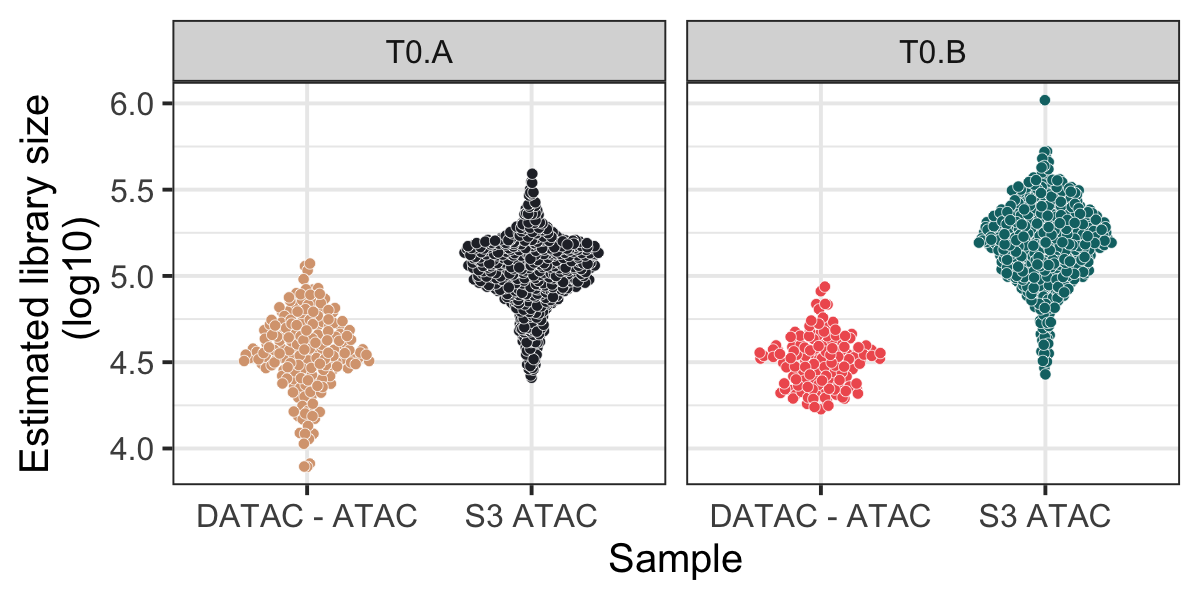

In [124]:
p <- ggplot(data = data, aes(x = mode, y =log10(libSize),  fill = sample))+
  #geom_boxplot(alpha = 0.25, outliers = F) +
  geom_quasirandom(
    dodge.width = 0.8,
    shape = 21,
    color = "white",
    alpha = 1,
    size = 3,
    stroke = 0.3,
    width = 0.3,         # how wide the cloud is
    varwidth = TRUE      # makes the dots follow density (violin shape)
  )+
  scale_color_manual(values = c("SW620bc_POTa_DATAC" ="#d8a47f",
                                "SW620bc_POTb_DATAC" ="#f05d5e",
                                "SW620bc_POTb_ATAC" ="#0f7173",
                                "SW620bc_POTa_ATAC" ="#272932"))+
  scale_fill_manual(values = c("SW620bc_POTa_DATAC" ="#d8a47f",
                               "SW620bc_POTb_DATAC" ="#f05d5e",
                               "SW620bc_POTb_ATAC" ="#0f7173",
                               "SW620bc_POTa_ATAC" ="#272932"))+
  xlab("Sample")+
  ylab("Estimated library size\n (log10)")+
  facet_wrap(vars(Rep), scales = "free_x", nrow = 1)+
  guides(color = "none", fill = "none")+
  theme_bw(base_size = 24)
options(repr.plot.width=10, repr.plot.height=5)
p

## Browser track at the GAPDH locus

In [93]:
set.seed(1)

my_pal <- c(
  "s3-ATAC: T0.A" = "#730d5d",
  "dATAC - ATAC: T0.A" = "#730d5d",
  "s3-ATAC: T0.B" = "#b81595",
  "dATAC - ATAC: T0.B" = "#b81595",
  "s3-ATAC: T1.A" = "#f077d6",
  "dATAC - ATAC: T1.A" = "#f077d6",
  "s3-ATAC: T1.B" = "#f8bceb",
  "dATAC - ATAC: T1.B" = "#f8bceb",
  "s3-ATAC: T4.A" = "#c9bcf8",
  "dATAC - ATAC: T4.A" = "#c9bcf8",
  "s3-ATAC: T4.B" = "#7e60ef",
  "dATAC - ATAC: T4.B" = "#7e60ef",
  "s3-ATAC: T11.A" = "#a25fef",
  "dATAC - ATAC: T11.A" = "#a25fef",
  "s3-ATAC: T12.B" = "#6113bc",
  "dATAC - ATAC: T12.B" = "#6113bc",
  "s3-ATAC: H1299" = "black",
  "dATAC - ATAC: H1299" = "black"
)

p <- plotBrowserTrack(
  ArchRProj = proj, 
  groupBy = "RepMode", 
  geneSymbol = "GAPDH", 
  upstream = 150000,
  downstream = 150000,
  baseSize = 10,
  maxCells = 1000,
  pal = my_pal
)

ArchR logging to : ArchRLogs/ArchR-plotBrowserTrack-dfed4346a7dc-Date-2026-02-25_Time-09-28-30.661255.log
If there is an issue, please report to github with logFile!

2026-02-25 09:28:31.358364 : Validating Region, 0.012 mins elapsed.



GRanges object with 1 range and 2 metadata columns:
      seqnames          ranges strand |     gene_id      symbol
         <Rle>       <IRanges>  <Rle> | <character> <character>
  [1]    chr12 6533927-6538374      + |        2597       GAPDH
  -------
  seqinfo: 24 sequences from hg38 genome


2026-02-25 09:28:31.442457 : Adding Bulk Tracks (1 of 1), 0.013 mins elapsed.

Getting Region From Arrow Files 1 of 18

Getting Region From Arrow Files 2 of 18

Getting Region From Arrow Files 3 of 18

Getting Region From Arrow Files 4 of 18

Getting Region From Arrow Files 5 of 18

Getting Region From Arrow Files 6 of 18

Getting Region From Arrow Files 7 of 18

Getting Region From Arrow Files 8 of 18

Getting Region From Arrow Files 9 of 18

Getting Region From Arrow Files 10 of 18

Getting Region From Arrow Files 11 of 18

Getting Region From Arrow Files 12 of 18

Getting Region From Arrow Files 13 of 18

Getting Region From Arrow Files 14 of 18

Getting Region From Arrow Files 15 of 18

Getting Region From Arrow Files 16 of 18

Getting Region From Arrow Files 17 of 18

Getting Region From Arrow Files 18 of 18

2026-02-25 09:28:40.183604 : Adding Feature Tracks (1 of 1), 0.159 mins elapsed.

2026-02-25 09:28:40.265435 : Adding Gene Tracks (1 of 1), 0.16 mins elapsed.

2026-02-25 09:

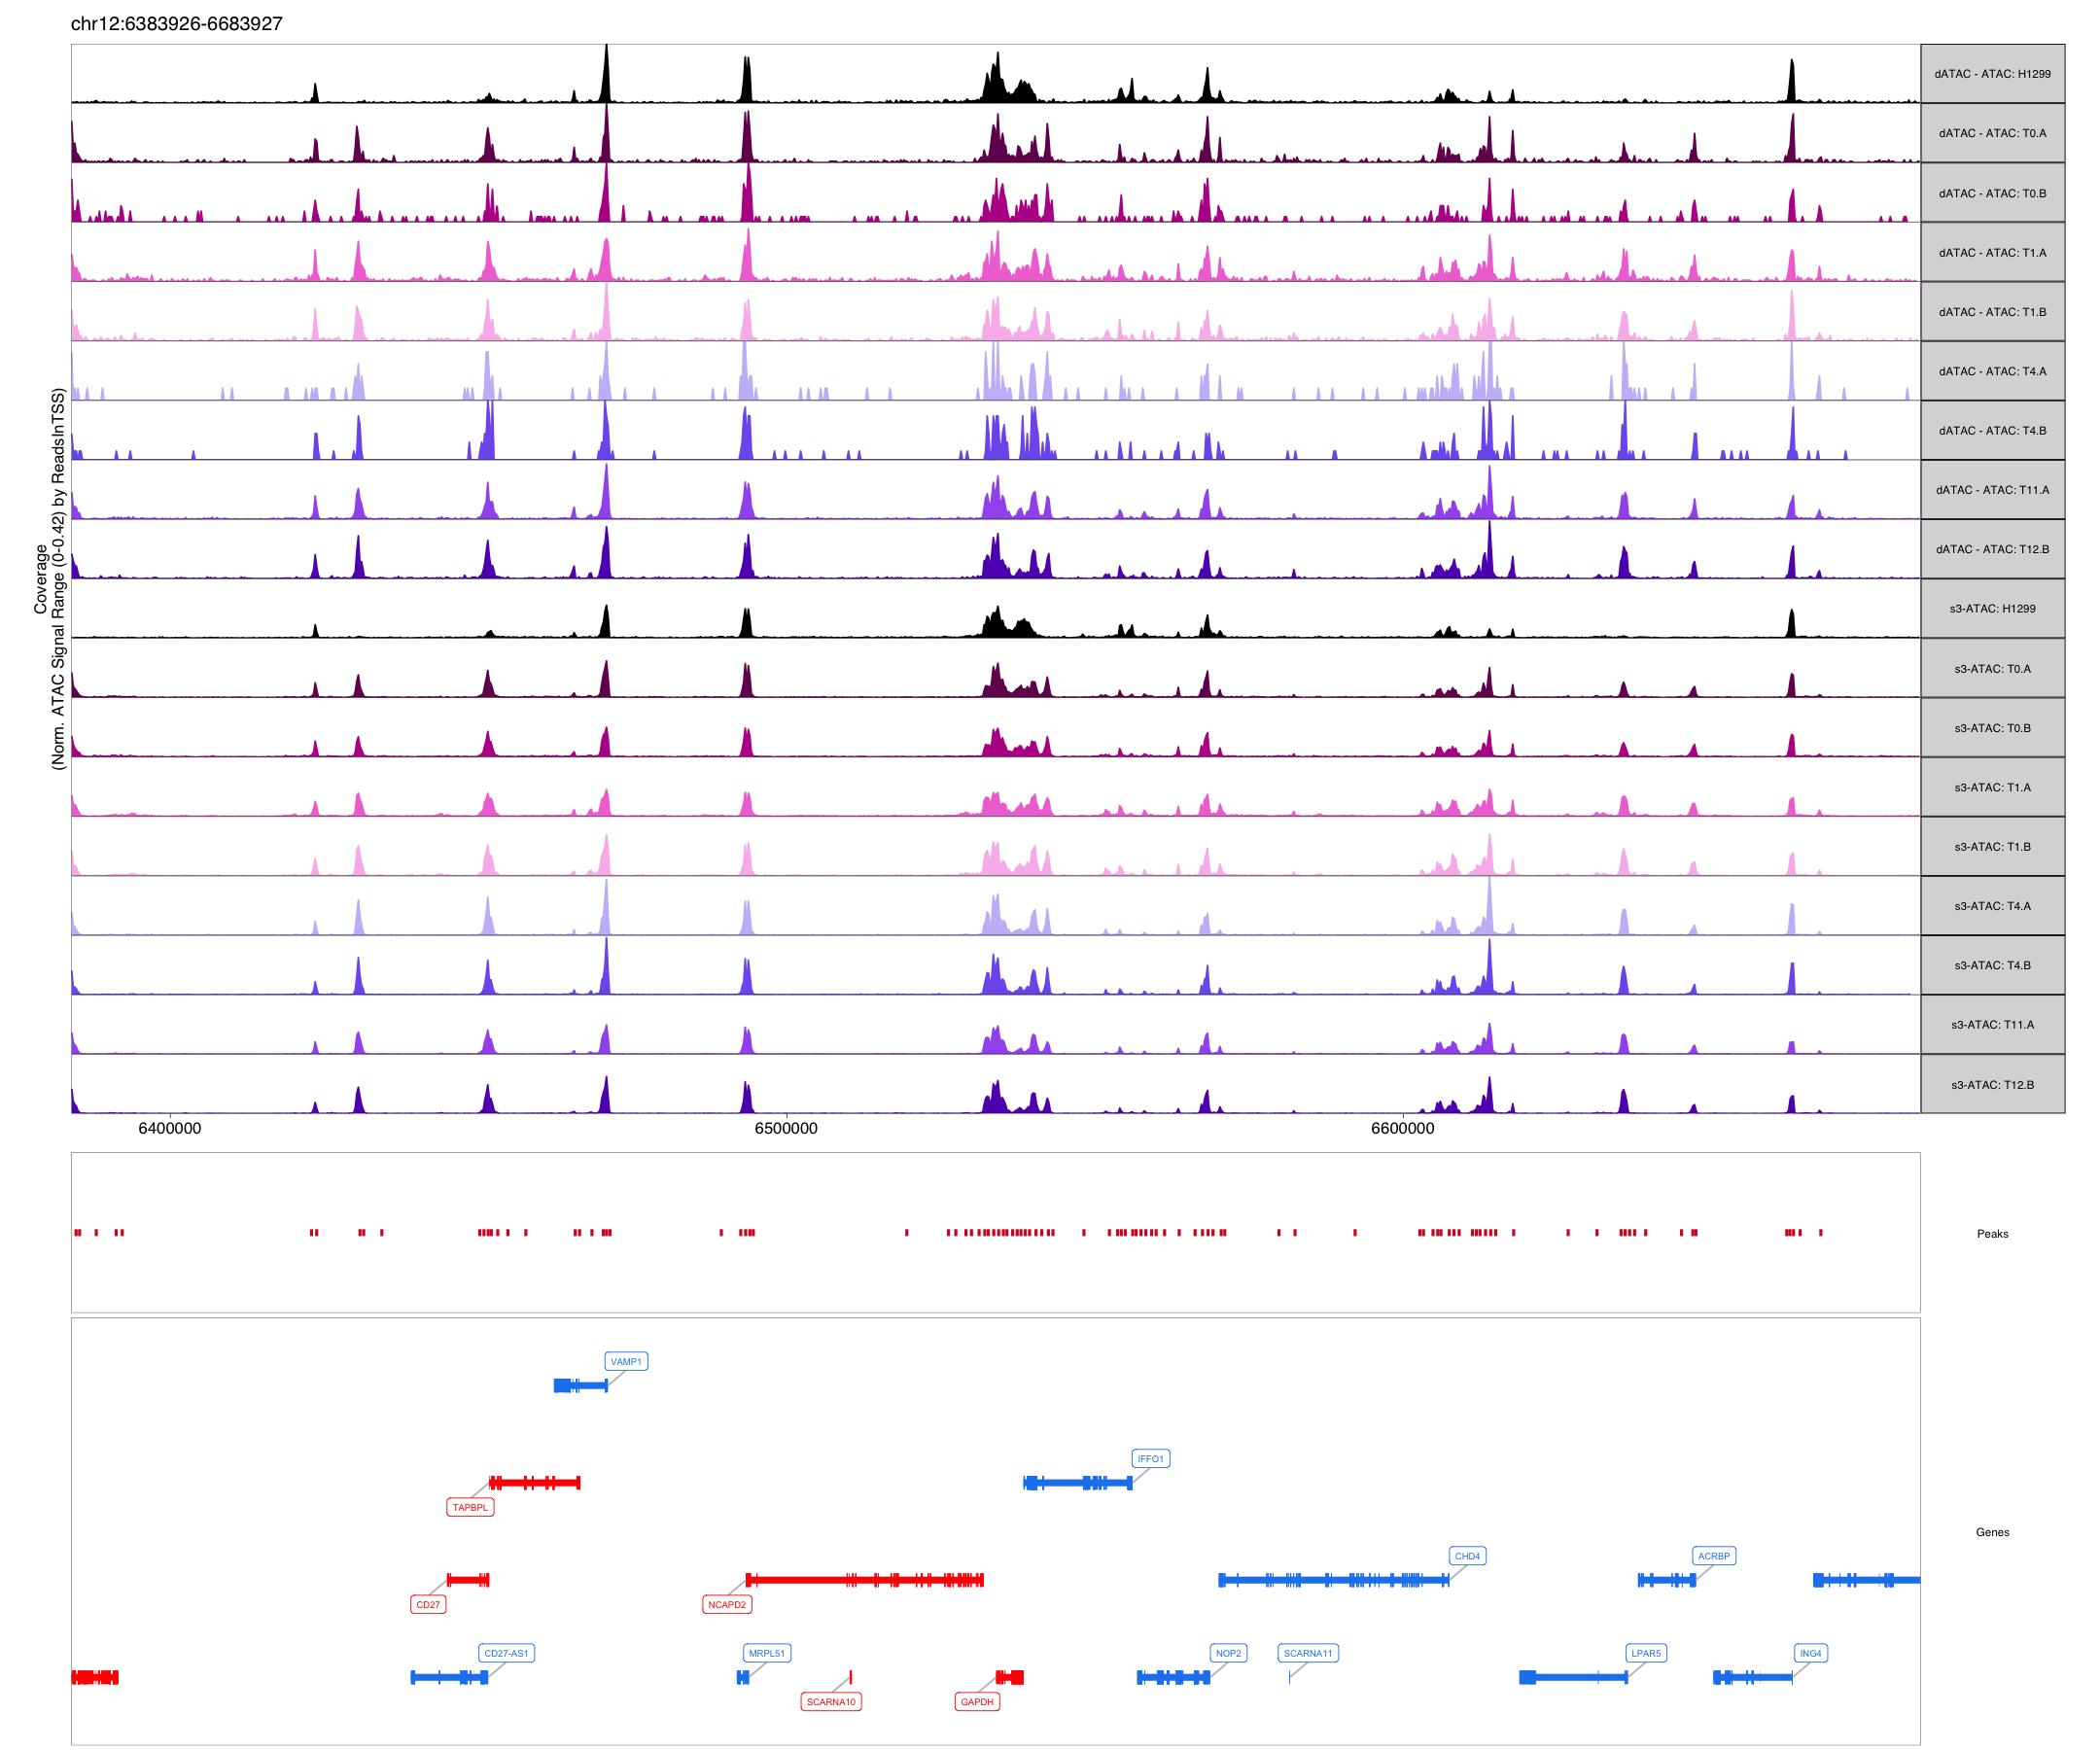

In [94]:
plot(p$GAPDH)

## Proportions of cells that pass each QC step, across timepoint

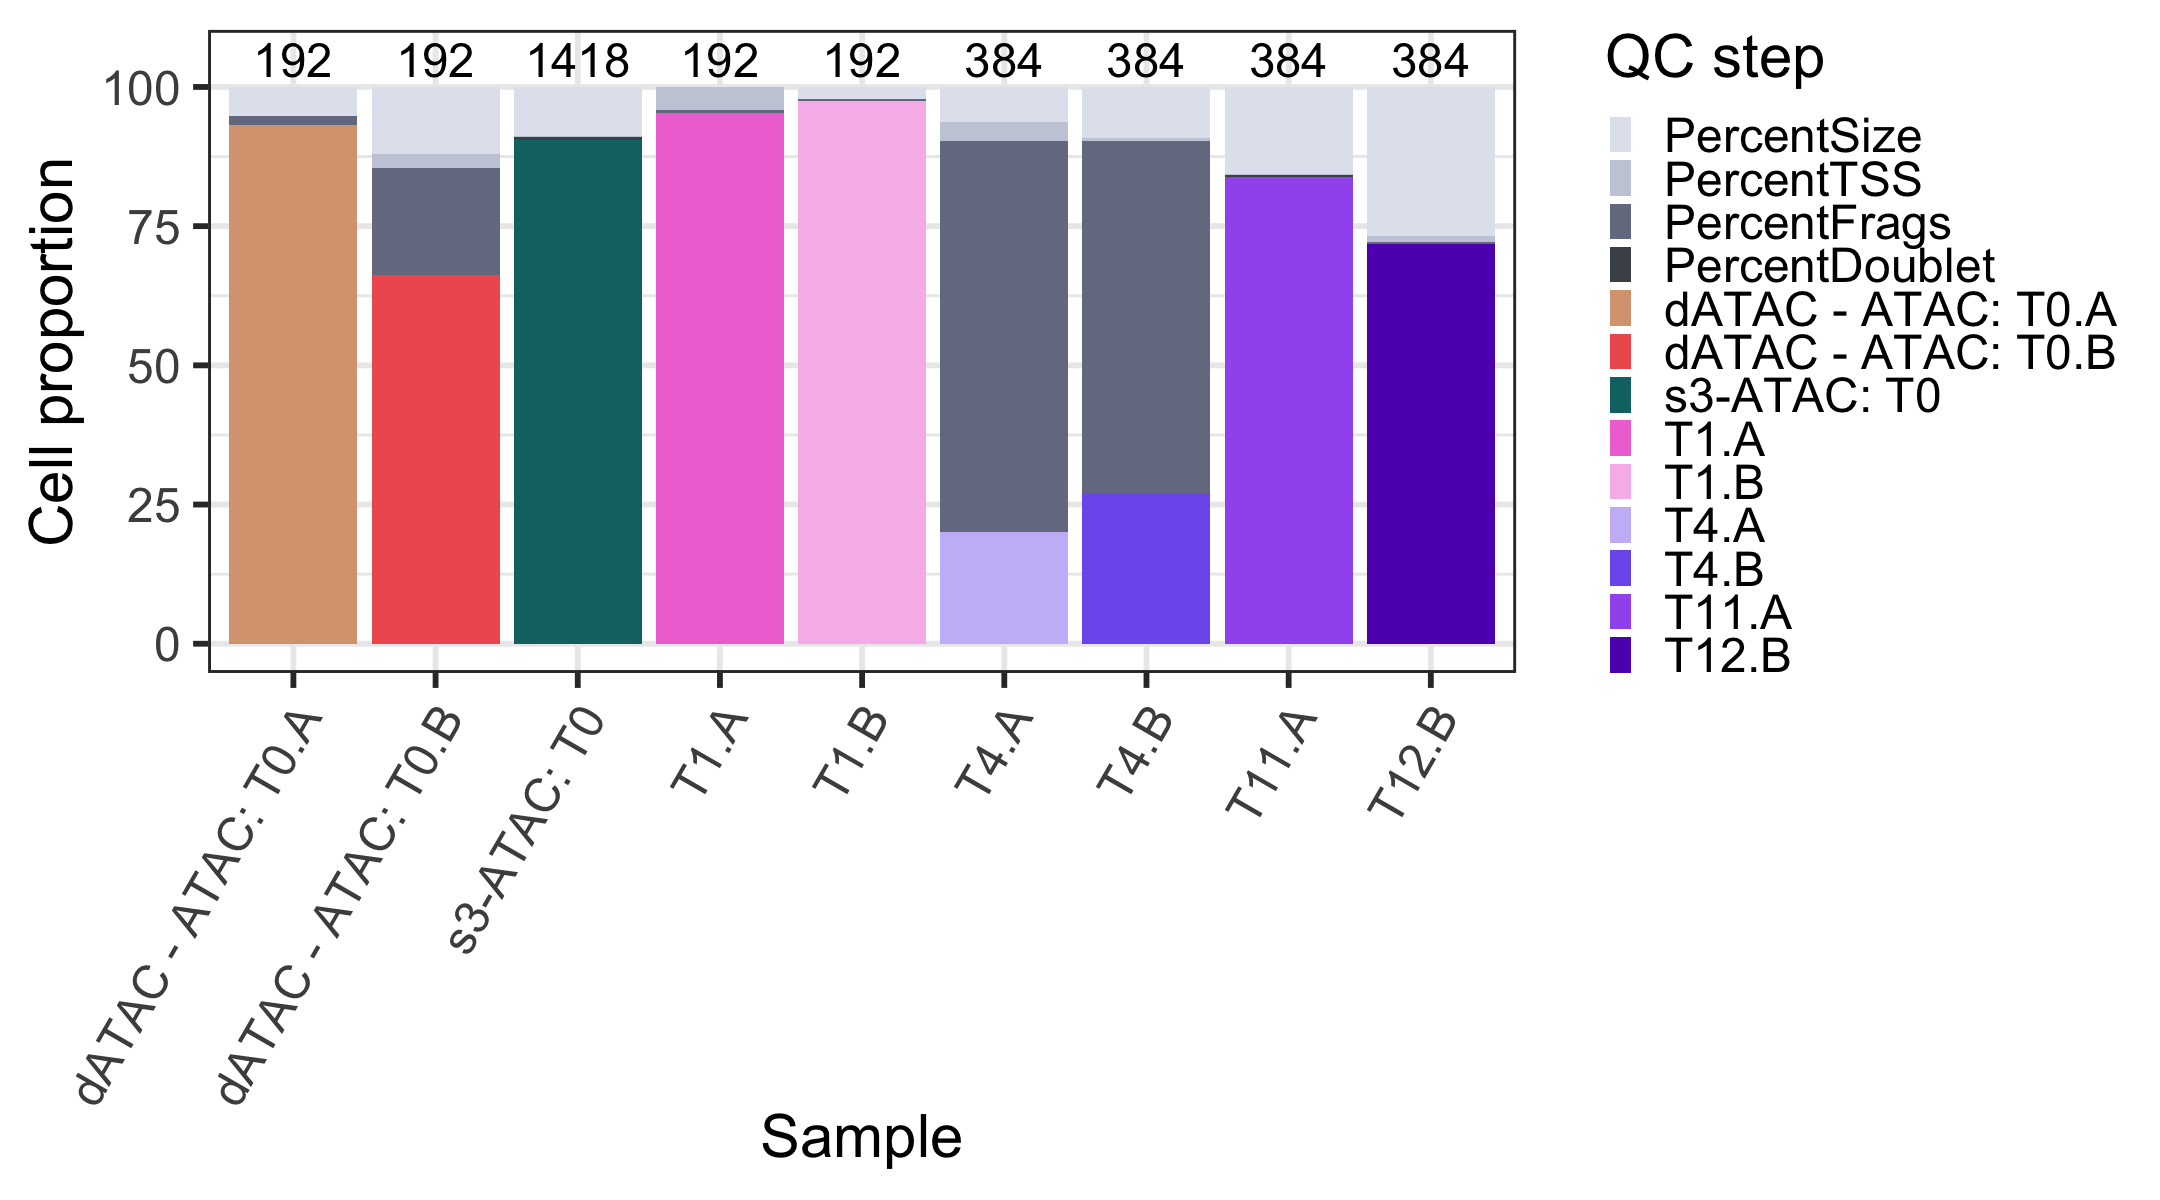

In [123]:
df <- data.frame(read_excel("../../Data/ATAC_Data/QC/ProportionCellsPassQC.xlsx")) 

df_long <- df %>% 
  filter(Sample %in% c("dATAC - ATAC: T0.A","dATAC - ATAC: T0.B","s3-ATAC: T0",
                        "T1.A","T1.B", "T4.A","T4.B",
                        "T11.A","T12.B")) %>%
  tidyr::pivot_longer(
    cols = starts_with("Percent"),
    names_to = "QC.metric",
    values_to = "Proportion"
  ) %>% 
 mutate(
    fill_var = if_else(
      QC.metric == "PercentPass",
      Sample,               # colour by sample
      QC.metric             # otherwise use QC.metric
    )
  ) 


df_long$QC.metric <- factor(df_long$QC.metric, levels = c("PercentSize","PercentTSS","PercentFrags","PercentDoublet","PercentPass"))
df_long$Sample <- factor(df_long$Sample, levels = c( "dATAC - ATAC: T0.A","dATAC - ATAC: T0.B","s3-ATAC: T0",
                                                        "T1.A","T1.B", "T4.A","T4.B",
                                                        "T11.A","T12.B"))
df_long$fill_var <- factor(df_long$fill_var, levels = c("PercentSize","PercentTSS","PercentFrags","PercentDoublet",
                                                       "dATAC - ATAC: T0.A","dATAC - ATAC: T0.B","s3-ATAC: T0",
                                                        "T1.A","T1.B", "T4.A","T4.B",
                                                        "T11.A","T12.B"))

p <- ggplot(data = df_long, aes(x = Sample, y =abs(Proportion),  fill = fill_var))+
  geom_col() +
  scale_fill_manual(name = "QC step",
                    values = c("PercentSize" = "#e1e5ee",
                               "PercentTSS" = "#c7ccdb",
                               "PercentFrags" = "#767b91",
                               "PercentDoublet" = "#495057",
                               "dATAC - ATAC: T0.A" = "#d8a47f",
                               "dATAC - ATAC: T0.B" = "#f05d5e",
                               "s3-ATAC: T0" =  "#0f7173",
                               "T1.A" =  "#f077d6",
                               "T1.B" =  "#f8bceb",
                               "T4.A" = "#c9bcf8",
                               "T4.B" = "#7e60ef",
                               "T11.A"= "#a25fef",
                               "T12.B"= "#6113bc"))+
  geom_text(data = df %>% filter(Sample %in% c("dATAC - ATAC: T0.A","dATAC - ATAC: T0.B","s3-ATAC: T0",
                        "T1.A","T1.B", "T4.A","T4.B",
                        "T11.A","T12.B")) %>% select(Sample, Total),
            aes(x =`Sample`, y = 105, label = Total),
            inherit.aes = F,# slightly above the bar
            size = 10
  ) +
  xlab("Sample")+
  ylab("Cell proportion")+
  theme_bw(base_size = 36)+
    theme(
        axis.text.x = element_text(angle = 60, hjust = 1)
    )
options(repr.plot.width=18, repr.plot.height=10)
p


## Venn diagrams of dATAC cells per sample that pass both ATAC and WGS QCs

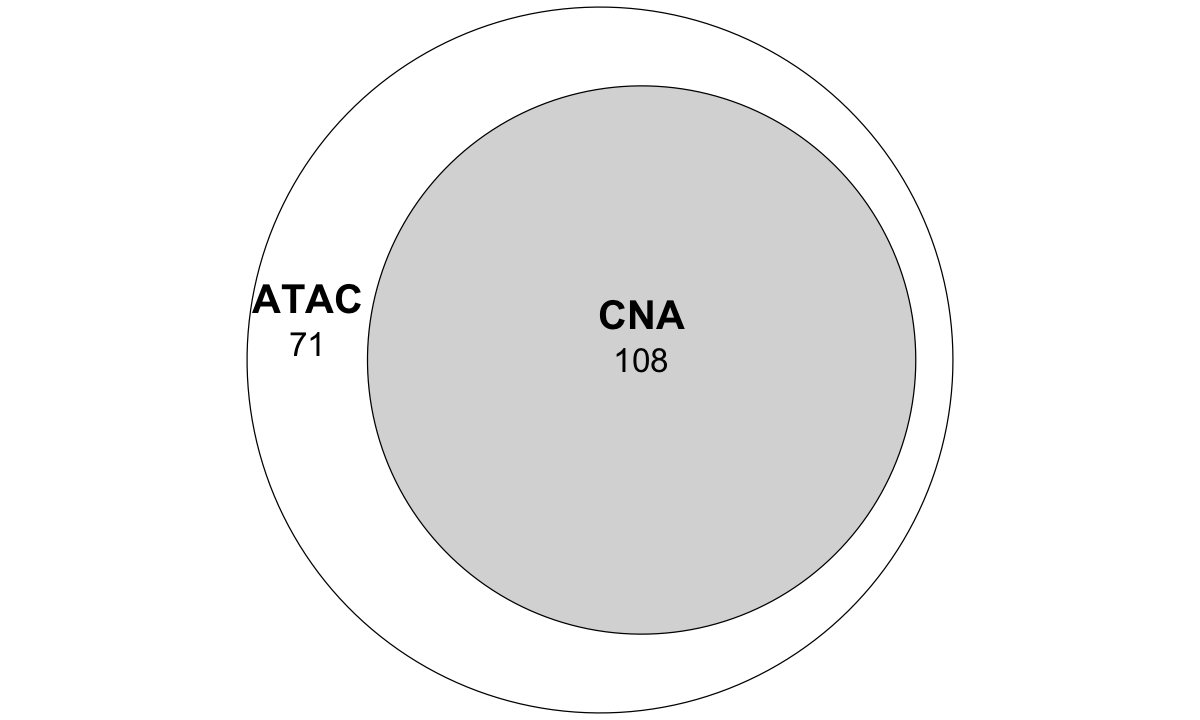

In [98]:
# Venn diagrams for cells passing both CNA and ATAC QC - POTa
options(repr.plot.width=10, repr.plot.height=6)
e <- euler(c("ATAC" = 71,
             "CNA"= 0,
             "ATAC&CNA" = 108))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))


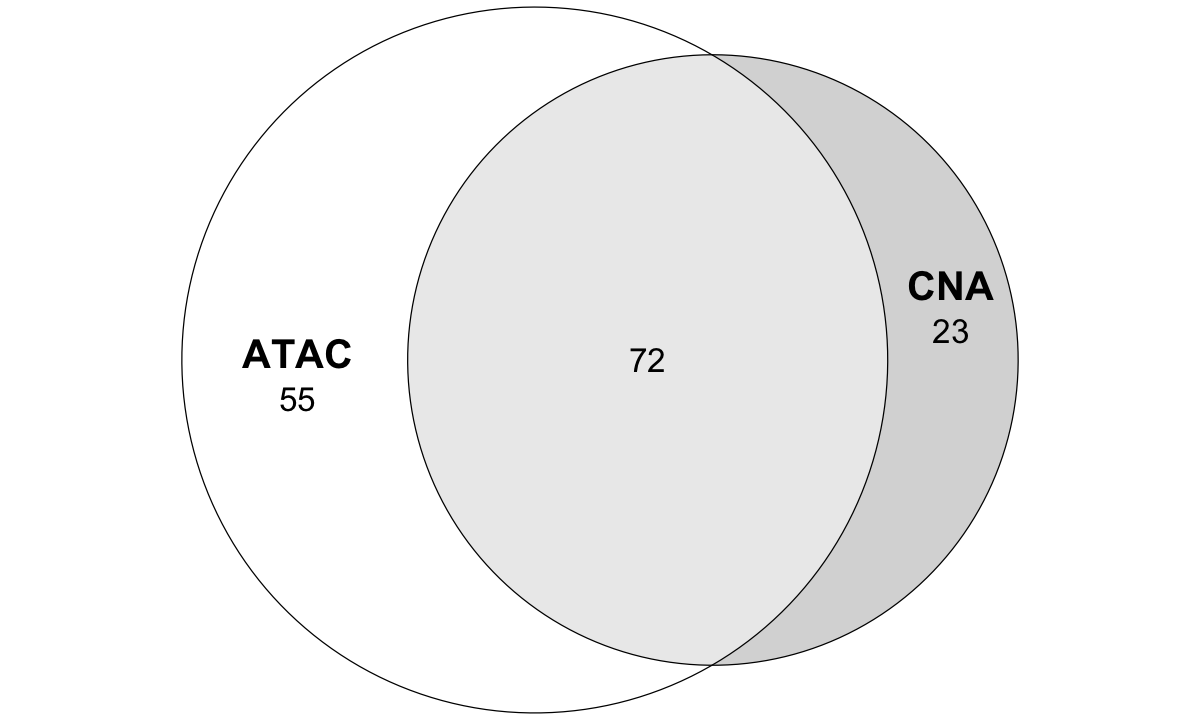

In [99]:
# Venn diagrams for cells passing both CNA and ATAC QC - POTb
options(repr.plot.width=10, repr.plot.height=6)
e <- euler(c("ATAC" = 55,
             "CNA"= 23,
             "ATAC&CNA" = 72))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))

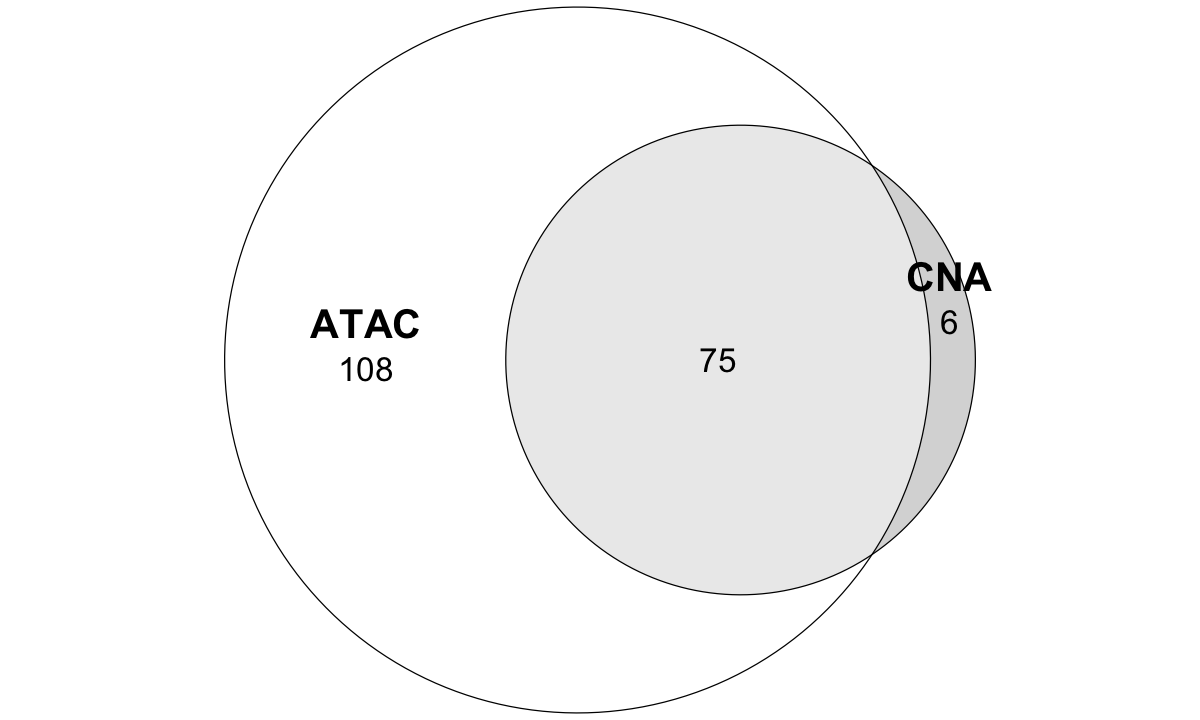

In [100]:
# Venn diagrams for cells passing both CNA and ATAC QC - DSIa
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 108,
             "CNA"= 6,
             "ATAC&CNA" = 75))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))


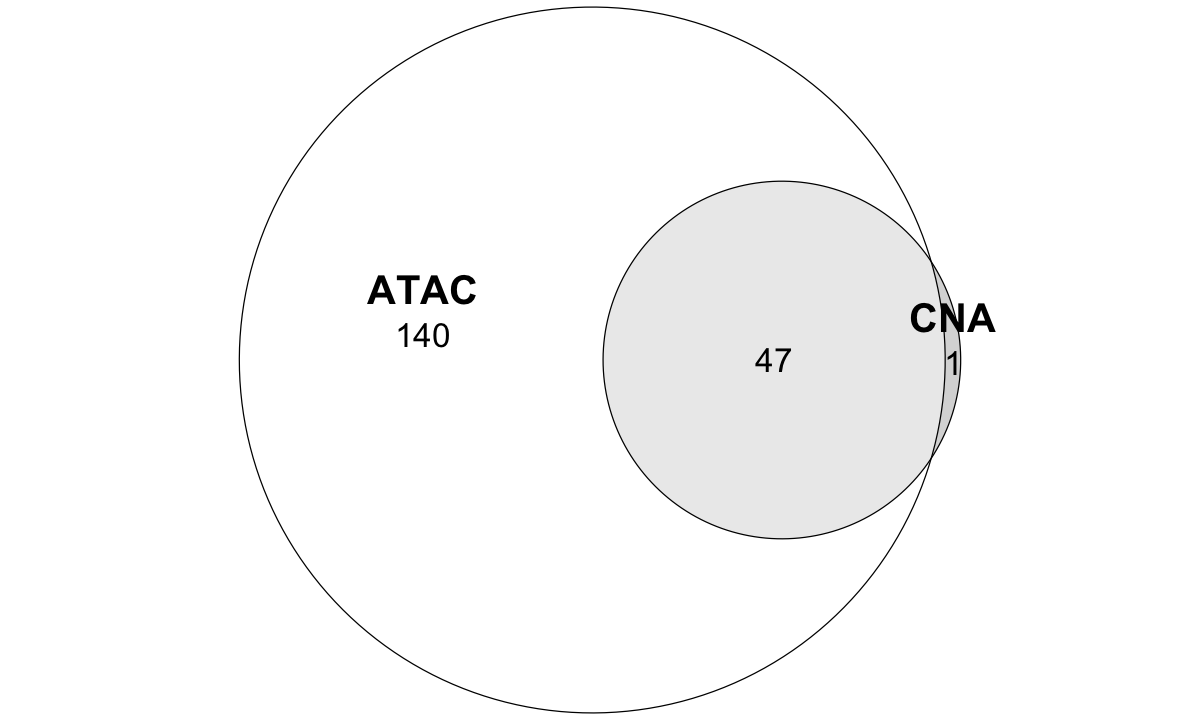

In [101]:
# Venn diagrams for cells passing both CNA and ATAC QC - DSIb
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 140,
             "CNA"= 1,
             "ATAC&CNA" = 47))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))

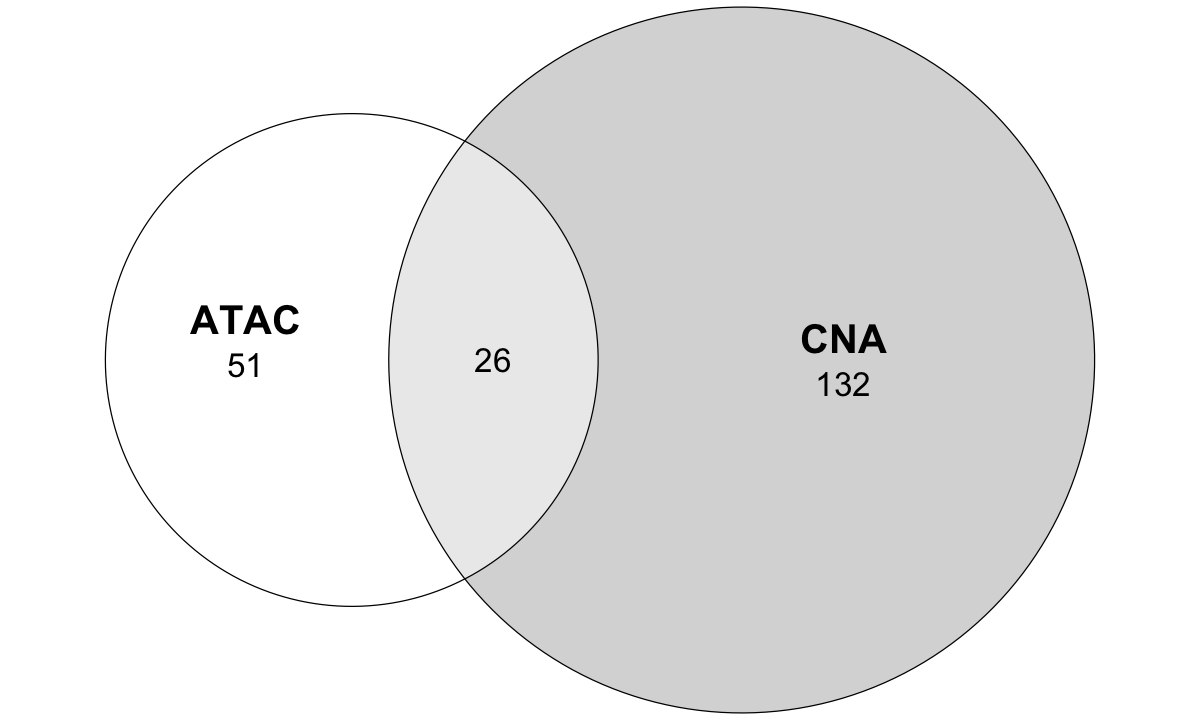

In [105]:
# Venn diagrams for cells passing both CNA and ATAC QC - DSIVa
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 51,
             "CNA"= 132,
             "ATAC&CNA" = 26))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))


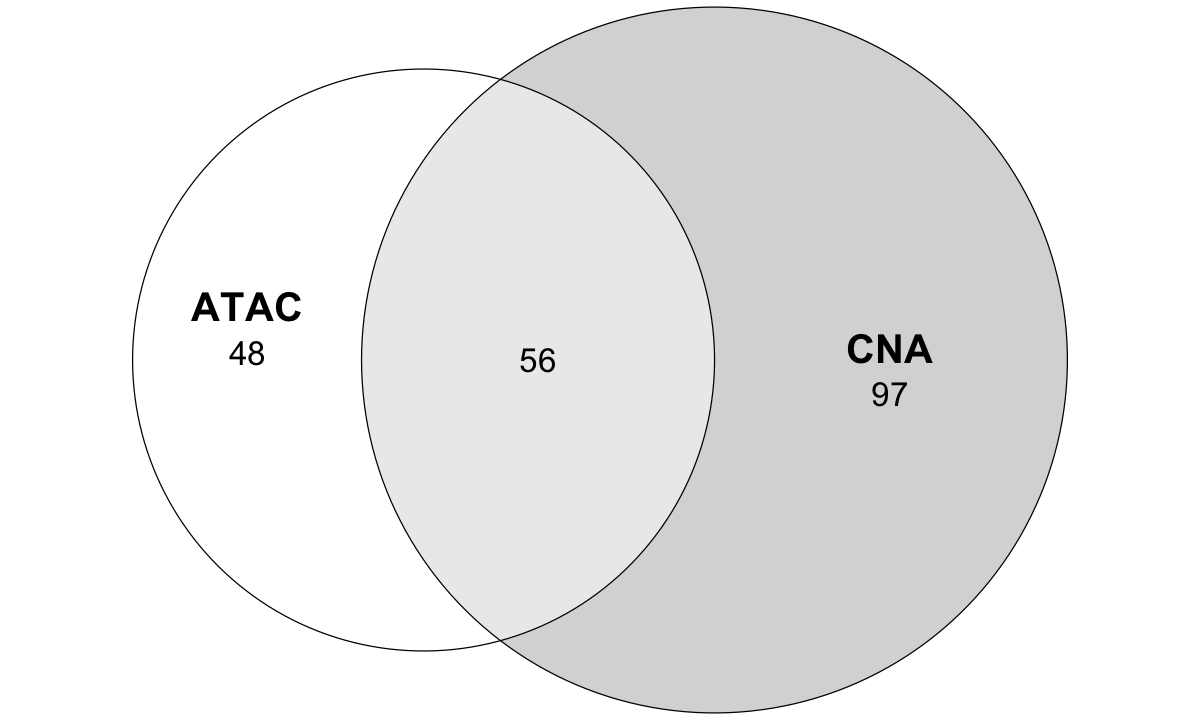

In [106]:
# Venn diagrams for cells passing both CNA and ATAC QC - DSIVb
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 48,
             "CNA"= 97,
             "ATAC&CNA" = 56))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))

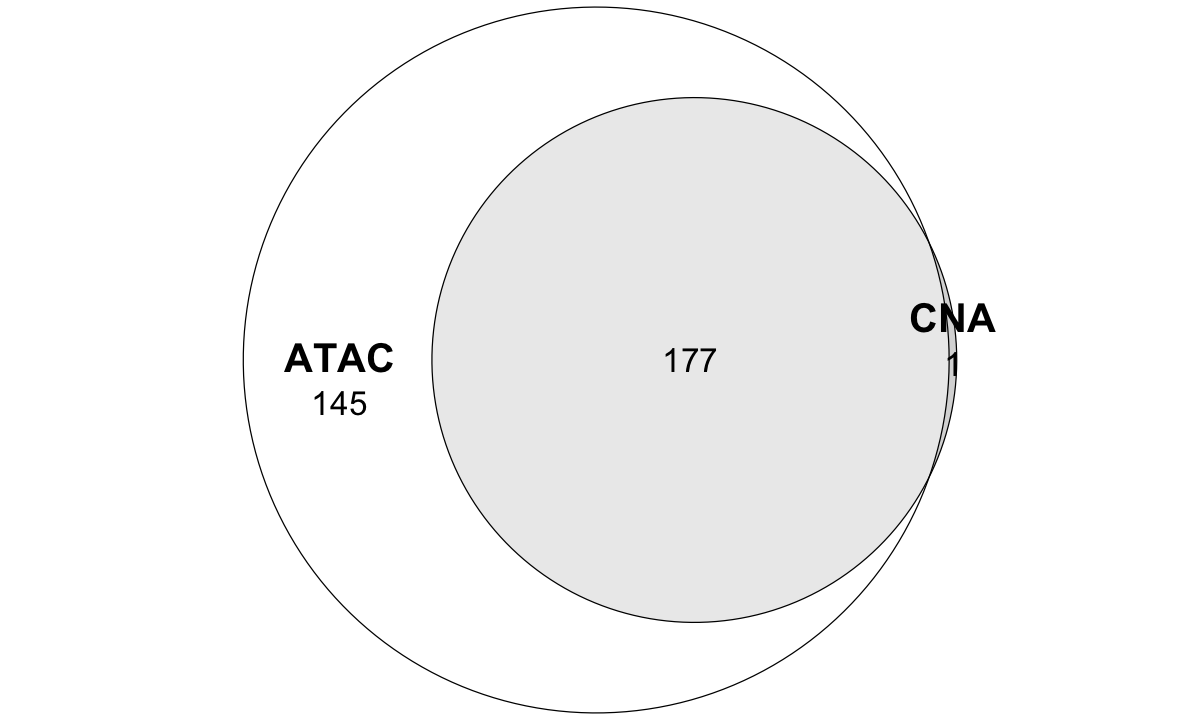

In [107]:
# Venn diagrams for cells passing both CNA and ATAC QC - DT1 P1a
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 145,
             "CNA"= 1,
             "ATAC&CNA" = 177))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))


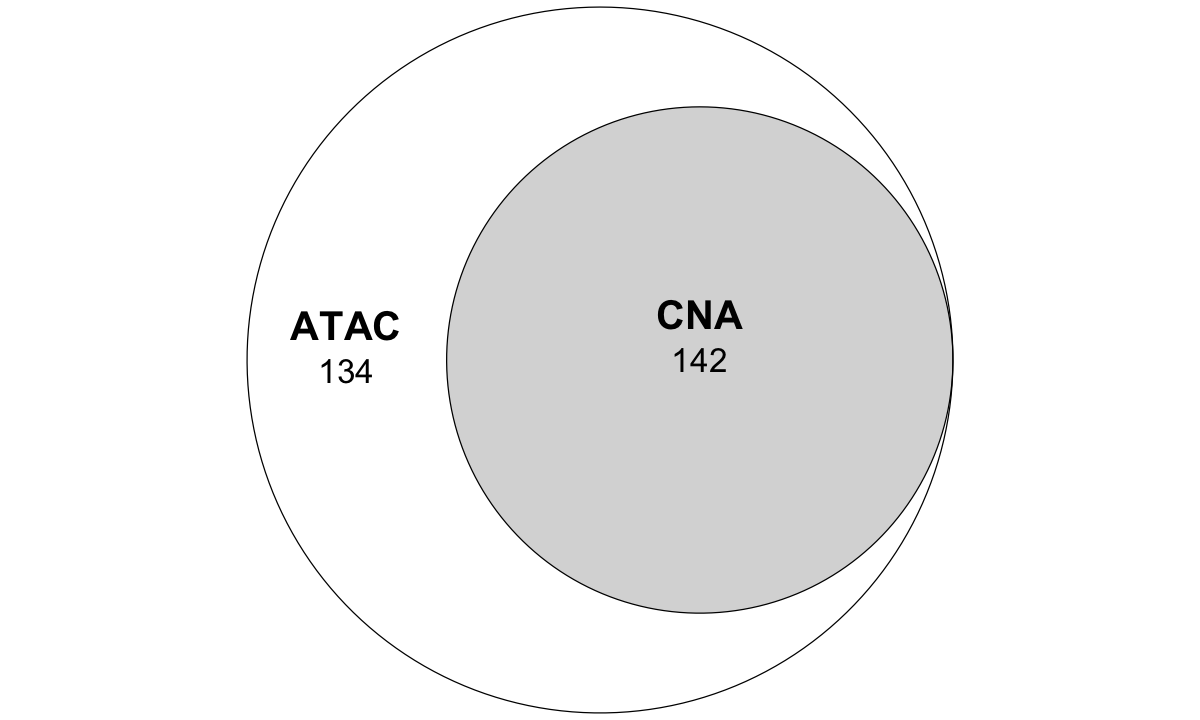

In [104]:
# Venn diagrams for cells passing both CNA and ATAC QC - DT1 P1b
options(repr.plot.width=10, repr.plot.height=6)

e <- euler(c("ATAC" = 134,
             "CNA"= 0,
             "ATAC&CNA" = 142))
plot(e, fontsize = 24, 
     quantities = list(fontsize = 20),
     labels = list(fontsize = 24))